# Product demand analysis

In [150]:
import pandas as pd
import numpy as np
import seaborn as sns
df=pd.read_csv('Amazon_Products.csv')
df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Microphones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Chargers & Power,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Microphones,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Headphones & Earbuds,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Networking & Smart Home,0.00


In [151]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


In [152]:
df=df.drop(columns=['product_image_url','product_page_url'])
df.head()


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,2025-08-21 11:14:29,Microphones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,2025-08-21 11:14:29,Chargers & Power,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,2025-08-21 11:14:29,Microphones,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,2025-08-21 11:14:29,Headphones & Earbuds,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,2025-08-21 11:14:29,Networking & Smart Home,0.00


Here, we removed columns that are not relevant for our analysis: `product_image_url`and `product_page_url`, . These are metadata columns that do not contribute to understanding product characteristics or performance. Dropping them simplifies the dataset and reduces memory usage.

# Quantitative and Qualitative features

In [153]:

quantiative_features=df[['total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']]
print("Quantitative features : ",quantiative_features.columns.to_list())

qualitative_features=df[['product_title', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'data_collected_at', 'product_category']]
print("Qualitative features : ",qualitative_features.columns.tolist())

Quantitative features :  ['total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']
Qualitative features :  ['product_title', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'delivery_date', 'sustainability_tags', 'data_collected_at', 'product_category']


In this step, we classified the features into **quantitative** (numeric) and **qualitative** (non-numeric) categories. The `select_dtypes(include=[np.number])` method extracts all numeric columns, while `select_dtypes(exclude=[np.number])` extracts non-numeric columns. This classification helps us understand which statistical methods are appropriate for each feature type.

# Data types

In [154]:
print(df.dtypes)

product_title            object
product_rating          float64
total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller           object
is_sponsored             object
has_coupon               object
buy_box_availability     object
delivery_date            object
sustainability_tags      object
data_collected_at        object
product_category         object
discount_percentage     float64
dtype: object


Using `df.dtypes`, we printed the data type of each column. This helps us verify whether columns are stored as the correct type (integer, float, object, etc.) and identify any columns that may need type conversion for proper analysis.

# Data Classification

In [155]:

nominal = ['product_title', 'is_best_seller', 'is_sponsored', 'has_coupon', 
           'buy_box_availability', 'sustainability_tags', 'product_category']

ordinal = ['product_rating']  

interval = [] 

ratio = ['total_reviews', 'purchased_last_month', 'discounted_price', 
         'original_price', 'discount_percentage']

print("4 LEVELS OF DATA CLASSIFICATION")
print(f"\n1. NOMINAL (No order):\n   {nominal}")
print(f"\n2. ORDINAL (Ordered):\n   {ordinal}")
print(f"\n3. INTERVAL (No true zero):\n   {interval}")
print(f"\n4. RATIO (True zero):\n   {ratio}")

4 LEVELS OF DATA CLASSIFICATION

1. NOMINAL (No order):
   ['product_title', 'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability', 'sustainability_tags', 'product_category']

2. ORDINAL (Ordered):
   ['product_rating']

3. INTERVAL (No true zero):
   []

4. RATIO (True zero):
   ['total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']


This code categorizes all features into the **four levels of data measurement**:

- **Nominal**: Categorical data with no inherent order (e.g., product_title, product_category)
- **Ordinal**: Categorical data with a meaningful order (e.g., product_rating with values 1-5)
- **Interval**: Numeric data with equal intervals but no true zero point (not present in this dataset)
- **Ratio**: Numeric data with equal intervals and a true zero point (e.g., price, count, discount)

This classification determines which statistical operations are valid for each feature.

# Descriptive statistics for numeric features

In [156]:
numeric_df = df.select_dtypes(include=[np.number])
#print(numeric_df.to_string())

descriptive_stats = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
    'Q1 (25%)': numeric_df.quantile(0.25),
    'Q2 (50%)': numeric_df.quantile(0.50),
    'Q3 (75%)': numeric_df.quantile(0.75),
    'Std Dev': numeric_df.std(),
    'Min': numeric_df.min(),
    'Max': numeric_df.max()
})

print("DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES")
descriptive_stats


DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES


,Mean,Median,Mode,Q1 (25%),Q2 (50%),Q3 (75%),Std Dev,Min,Max
product_rating,4.399431,4.50,4.60,4.20,4.50,4.70,0.386997,1.00,5.00
total_reviews,3087.106000,343.00,25.00,82.00,343.00,1886.00,13030.460133,1.00,865598.00
purchased_last_month,1293.665278,200.00,100.00,100.00,200.00,400.00,6318.323574,50.00,100000.00
discounted_price,243.227289,84.99,29.99,29.69,84.99,224.00,473.351545,2.16,5449.00
original_price,257.611107,89.00,29.99,32.99,89.00,229.99,496.633495,2.16,5449.00
discount_percentage,6.547151,0.00,0.00,0.00,0.00,8.49,12.744715,0.00,85.42


We calculated **descriptive statistics** for all numeric features:

- **Mean**: The average value of the data
- **Median**: The middle value when data is sorted (also Q2)
- **Mode**: The most frequently occurring value
- **Q1 (25th percentile)**: Value below which 25% of data falls
- **Q2 (50th percentile)**: The median value
- **Q3 (75th percentile)**: Value below which 75% of data falls
- **Standard Deviation**: Measures how spread out the values are from the mean

These statistics provide insights into the central tendency, distribution, and variability of the data.

In [157]:
# import matplotlib.pyplot as plt

# numeric_cols = df.select_dtypes(include=[np.number]).columns

# fig, axes = plt.subplots(6, 1, figsize=(10, 30))
# axes = axes.flatten()  # Flatten to 1D array for easy indexing

# for i, col in enumerate(numeric_cols):  # This defines 'i' and 'col'
#     axes[i].hist(df[col].dropna(),bins=50)
#     axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.2f}')
#     axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
#     axes[i].axvline(df[col].median(), color='green', label='Median')
#     axes[i].legend()


# plt.show()

# Histogram plots for all features

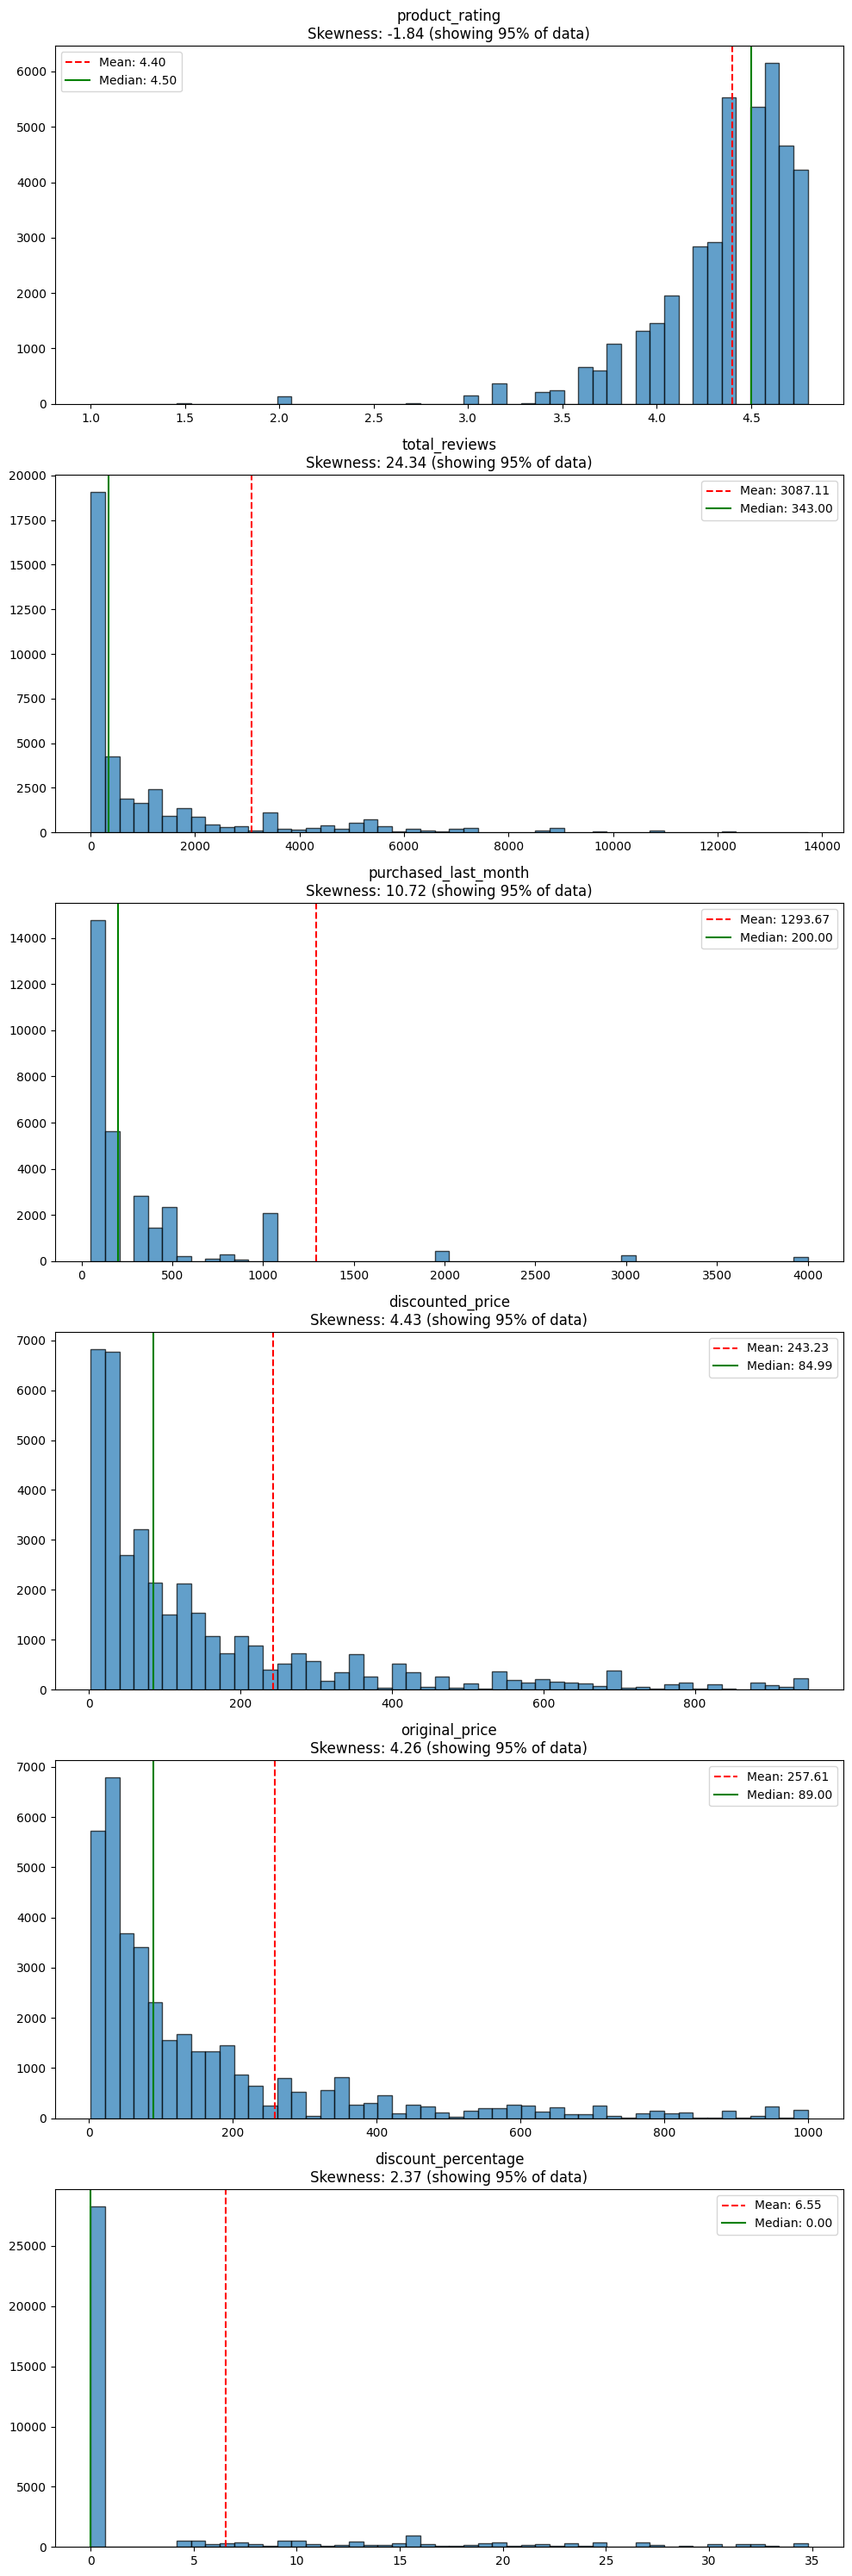

In [158]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(6, 1, figsize=(10, 30))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    # Filter to 95th percentile for better visualization
    upper_limit = data.quantile(0.95)
    filtered_data = data[data <= upper_limit]
    
    axes[i].hist(filtered_data, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}\nSkewness: {data.skew():.2f} (showing 95% of data)')
    
    # Only show mean/median if within visible range
    mean_val = data.mean()
    median_val = data.median()
    if mean_val <= upper_limit:
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    if median_val <= upper_limit:
        axes[i].axvline(median_val, color='green', label=f'Median: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Missing Data

In [159]:
df.isnull().sum()

product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

# Handling Missing Data

In [160]:
df.dropna(subset=['purchased_last_month'], inplace=True)

df['product_rating'].fillna(df['product_rating'].median(), inplace=True)

df['total_reviews'].fillna(df['total_reviews'].median(), inplace=True)

df['discount_percentage'].fillna(0,inplace=True)

calculated_original = df['discounted_price'] / (1 - df['discount_percentage']/100)
df['original_price'].fillna(calculated_original, inplace=True)
df['original_price'].fillna(df['original_price'].median(), inplace=True)

df['discounted_price']=df['original_price']-(df['discount_percentage']/100)*df['original_price']


df['buy_box_availability'].fillna("None",inplace=True)
df['sustainability_tags'].fillna("None",inplace=True)

df['delivery_date'] = df['delivery_date'].ffill
df.isnull().sum()

product_title           0
product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
is_best_seller          0
is_sponsored            0
has_coupon              0
buy_box_availability    0
delivery_date           0
sustainability_tags     0
data_collected_at       0
product_category        0
discount_percentage     0
dtype: int64

### 1. **purchased_last_month** - Deletion (`dropna`)
- Dropped all rows with missing values
- This is our **target variable** for demand prediction. Without it, these rows provide no value for our analysis. Imputation would be inappropriate as we cannot accurately estimate demand without actual data.

### 2. **product_rating** - Median Imputation
- Filled with median rating
- Median is robust to outliers and represents the "typical" rating. Using mean could be skewed by extreme ratings (1 or 5 stars). Median provides a conservative, middle-ground estimate.

### 3. **total_reviews** - Median Imputation
- Filled with median review count
- Review counts are often **heavily right-skewed** (few products have thousands of reviews). Median is more representative of typical products than mean, which would be inflated by viral/popular items.

### 4. **discount_percentage** - Zero Fill
- Filled with 0
- Missing discount percentage logically means **no discount was applied**. This is a domain-knowledge driven decision where absence of data implies absence of discount.

### 5. **original_price** - Calculated Imputation + Median Fallback
- 
  1. First, calculated from: `discounted_price / (1 - discount_percentage/100)`
  2. Then filled remaining with median
- When discount information exists, we can **mathematically derive** the original price. For remaining missing values, median provides a reasonable estimate without introducing extreme values.

### 6. **discounted_price** - Forward Fill with original_price
- Calculated using original price and discount percentage

### 7. **buy_box_availability** & **sustainability_tags** - "None" Fill
- Filled with string "None"
- These are categorical features where missing values indicate the **absence of that attribute** (no buy box, no sustainability certification). "None" explicitly marks this absence for analysis.

### 8. **delivery_date** - Forward Fill
- Forward fill (propagate last valid value)
- Delivery dates may follow temporal patterns. Forward filling assumes similar delivery timelines for consecutive products, though this column appears optional in the dataset.



# Handling Duplicates

In [161]:
print(df.duplicated().sum())
print(df.shape)
print("After dropping duplicates")
df.drop_duplicates(keep='first',inplace=True,ignore_index=True)
print(df.shape)


0
(32164, 15)
After dropping duplicates
(32164, 15)


The original dataset did not contained duplicate entries.
- Original rows: 32,164
- Clean dataset: 32,164 unique products

# Unique values analysis for categorical features

In [162]:
categorical_cols = ['product_category', 'is_best_seller', 'is_sponsored', 
                    'has_coupon', 'buy_box_availability', 'sustainability_tags']

print("UNIQUE VALUE ANALYSIS FOR CATEGORICAL FEATURES")

for col in categorical_cols:
    if col in df.columns:
        total = len(df[col])
        value_counts = df[col].value_counts()
        unique_count = df[col].nunique()
        dominant_pct = (value_counts.iloc[0] / total) * 100
        
        print(f"\n {col} | {unique_count} unique values | Dominant: {dominant_pct:.1f}%")
        print(f"{'Value':<45} {'Count':>7} {'%':>7}")
        
        display_values = value_counts if unique_count <= 20 else value_counts.head(10)
        
        for val, count in display_values.items():
            pct = (count / total) * 100
            print(f"{str(val):<45} {count:>7} {pct:>6.1f}%")
        
        if unique_count > 20:
            print(f"  ... and {unique_count - 10} more values")
        
        print(f"{'TOTAL':<45} {total:>7} {'100.0%':>7}")

UNIQUE VALUE ANALYSIS FOR CATEGORICAL FEATURES

 product_category | 22 unique values | Dominant: 13.1%
Value                                           Count       %
Chargers & Power                                 4212   13.1%
Other Electronics                                3828   11.9%
Batteries                                        2420    7.5%
Printers & Scanners                              2420    7.5%
Laptops & Computers                              2136    6.6%
Microphones                                      2044    6.4%
Cameras & Photography                            1999    6.2%
Gaming                                           1706    5.3%
Headphones & Earbuds                             1463    4.5%
Speakers & Audio                                 1458    4.5%
  ... and 12 more values
TOTAL                                           32164  100.0%

 is_best_seller | 9 unique values | Dominant: 94.7%
Value                                           Count       %
No Badge     

Here we can see the no of unique values for different categorical features

# Histograms before outlier handling

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage'],
      dtype='object')


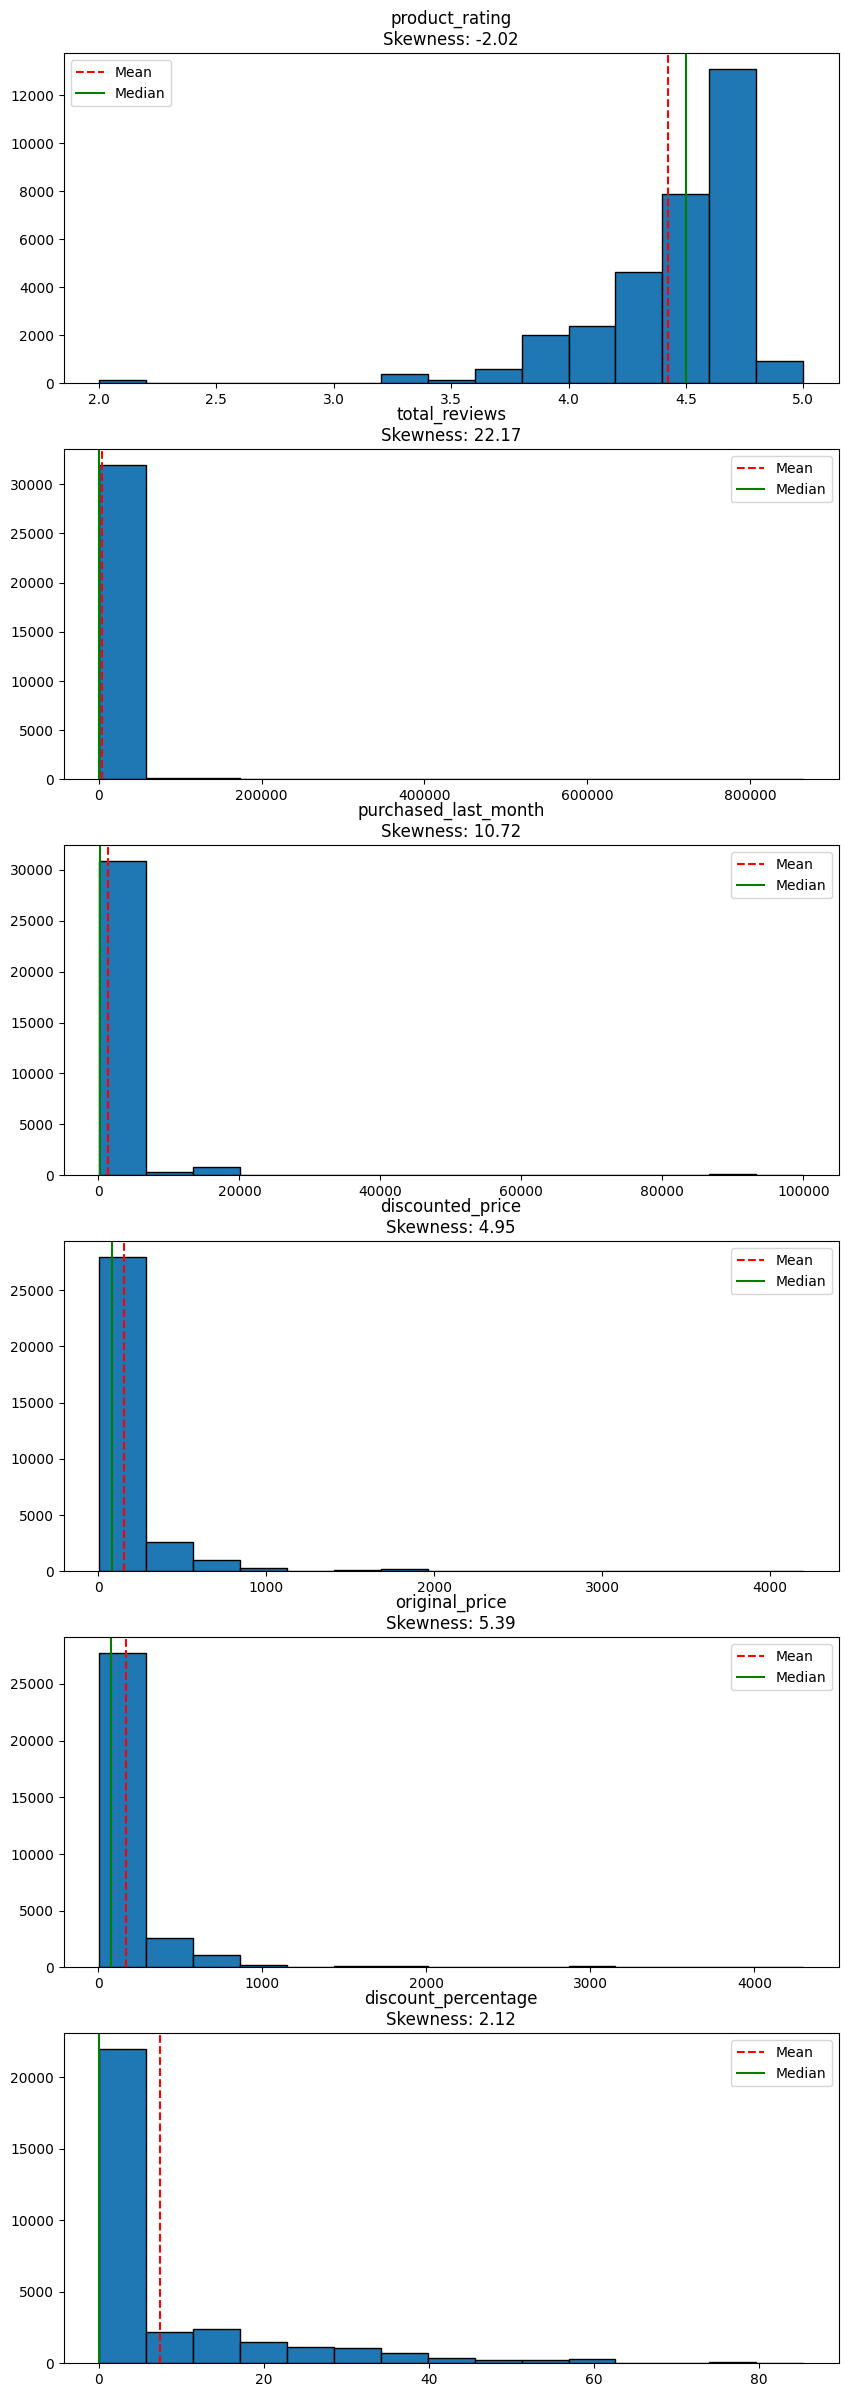

In [163]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)
fig, axes = plt.subplots(6, 1, figsize=(10, 30))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i, col in enumerate(numeric_cols):  
    axes[i].hist(df[col],bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.2f}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', label='Median')
    axes[i].legend()


plt.show()

# Descriptive statistics before outler handling

In [164]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,32164.000000,32164.000000,32164.000000,32164.000000,32164.000000,32164.000000
mean,4.422839,3773.170128,1293.665278,152.192892,167.631013,7.384987
std,0.366935,14609.205901,6318.323574,251.280072,297.944862,13.304639
min,2.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.300000,155.000000,100.000000,25.655000,29.990000,0.000000
50%,4.500000,686.000000,200.000000,78.990000,78.990000,0.000000
75%,4.700000,2685.000000,400.000000,168.992500,185.000000,11.110000
max,5.000000,865598.000000,100000.000000,4198.000000,4299.000000,85.420000


# Fining Outliers

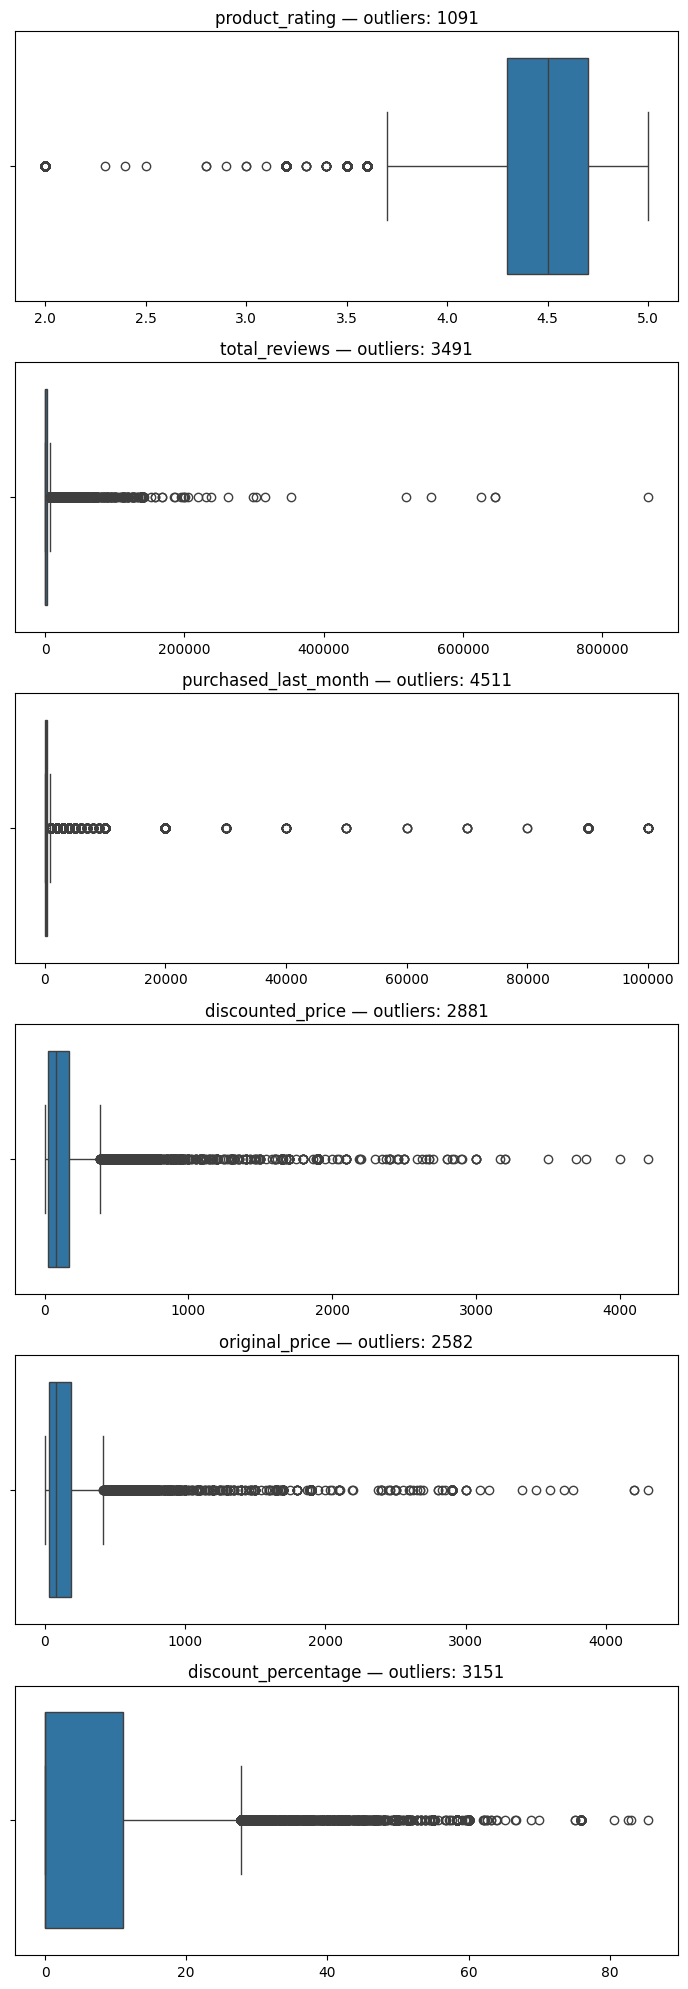

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(6,1, figsize=(7, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    minimum = max(data.min(), lower_bound)
    maximum = min(data.max(), upper_bound)

    outlier_mask = (data < minimum) | (data > maximum)
    outlier_count = int(outlier_mask.sum())

    sns.boxplot(x=data, ax=axes[i])
    axes[i].set_title(f"{col} — outliers: {outlier_count}")
    axes[i].set_xlabel('')


plt.tight_layout()
plt.show()

## Outlier handling 
- `purchased_last_month` and `total_reviews` → `log1p` variants.
- `original_price` and `discounted_price` → capped at 99th percentile and `log1p` variants.


In [166]:
import numpy as np

for col in ['purchased_last_month', 'total_reviews']:
    if col in df.columns:
        df[col] = np.log1p(df[col])
for col in ['original_price', 'discounted_price','discount_percentage']:
    if col in df.columns:
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=p99)



# Descriptive statistics after outlier handling

In [167]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,32164.000000,32164.000000,32164.000000,32164.000000,32164.000000,32164.000000
mean,4.422839,6.442963,5.396987,148.770254,161.564557,7.323159
std,0.366935,2.019204,1.363389,224.970884,252.147011,13.026987
min,2.000000,0.693147,3.931826,2.160000,2.160000,0.000000
25%,4.300000,5.049856,4.615121,25.655000,29.990000,0.000000
50%,4.500000,6.532334,5.303305,78.990000,78.990000,0.000000
75%,4.700000,7.895808,5.993961,168.992500,185.000000,11.110000
max,5.000000,13.671177,11.512935,1586.400000,1699.990000,58.380000


# Histograms after outlier handling

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage'],
      dtype='object')


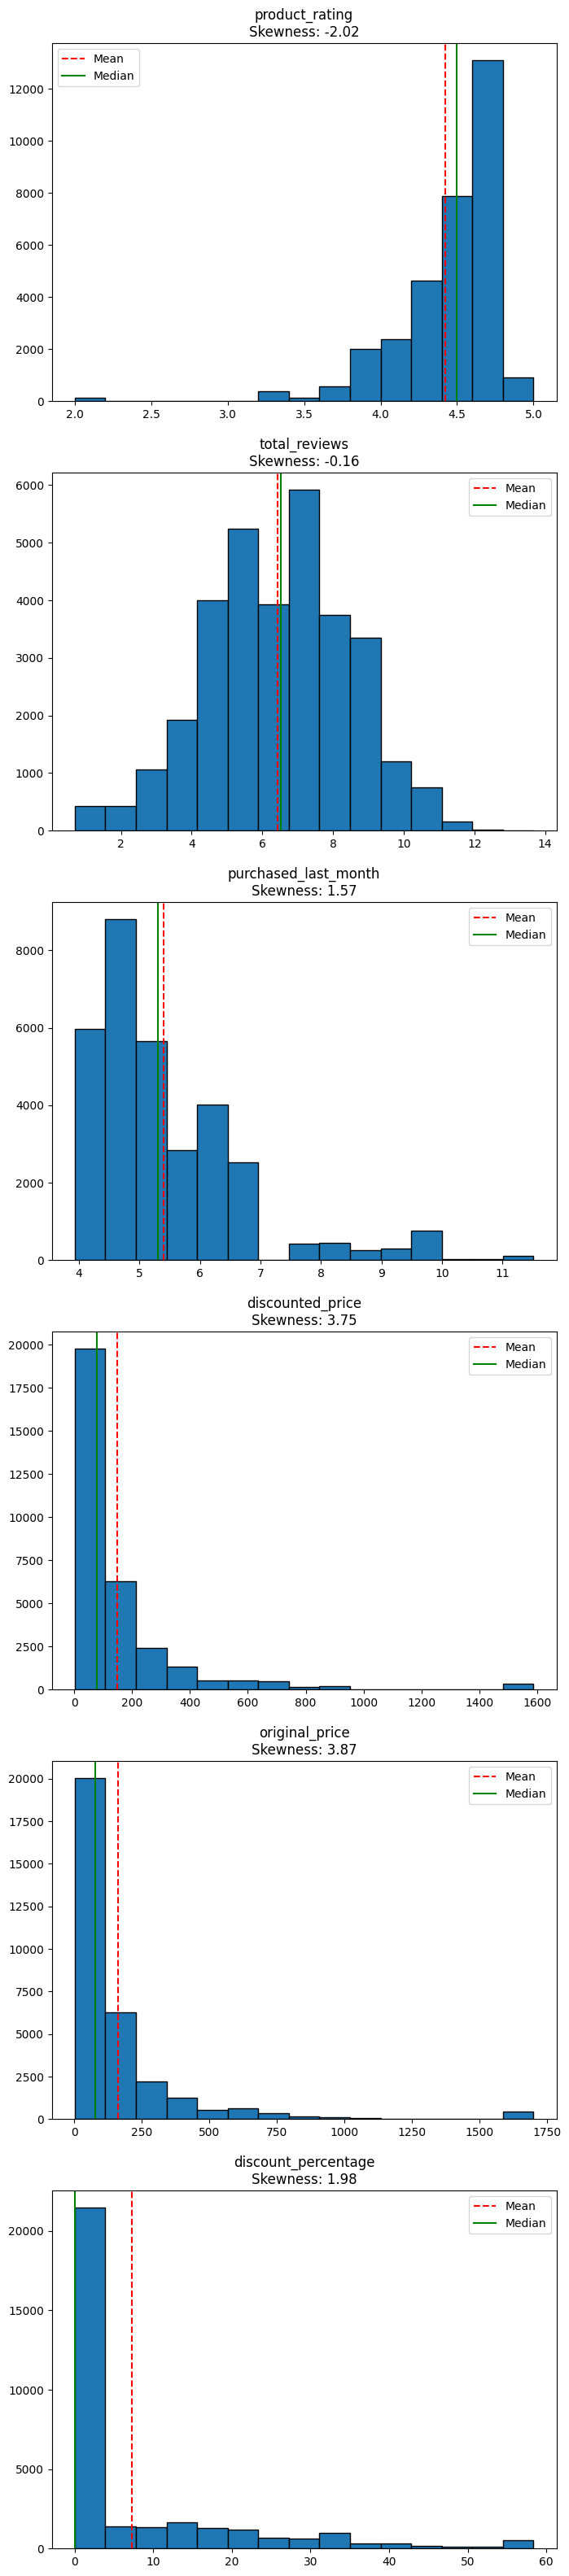

In [168]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)
fig, axes = plt.subplots(6, 1, figsize=(8, 40))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i, col in enumerate(numeric_cols):  
    axes[i].hist(df[col],bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\nSkewness: {df[col].skew():.2f}')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', label='Median')
    axes[i].legend()


plt.show()

In [ ]:
# Create isolated copies
# df_model: only for feature engineering/model training
# df_eda: only for exploratory analysis and temporary plotting columns
df_base = df.copy()
df_model = df_base.copy()
df_eda = df_base.copy()

# Keep downstream modeling section on model copy
df = df_model

print('Created isolated dataframes: df_model and df_eda')
print('Model dataframe shape:', df_model.shape)
print('EDA dataframe shape:', df_eda.shape)

## Dataframe Isolation for EDA vs Modeling
We split the cleaned dataset into two separate copies so temporary EDA columns never affect model features.

# Encoding and Normalization


In [ ]:
# 1. Separate target FIRST from model dataframe
y = df_model['purchased_last_month'].copy()

# 2. Drop irrelevant columns from model dataframe
X = df_model.drop(columns=['purchased_last_month', 'product_title', 'delivery_date', 'data_collected_at'])

# 3. Binary encoding
X['has_coupon'] = (X['has_coupon'] != 'No Coupon').astype(int)
X['is_best_seller'] = (X['is_best_seller'] != 'No Badge').astype(int)
X['is_sponsored'] = (X['is_sponsored'] == 'Sponsored').astype(int)
X['buy_box_availability'] = (X['buy_box_availability'] == 'Add to cart').astype(int)
X['sustainability_tags'] = (X['sustainability_tags'] != 'None').astype(int)

# 4. One-Hot Encode product_category
X = pd.get_dummies(X, columns=['product_category'])

print('Model features prepared from df_model only.')
print('X shape:', X.shape)
print('Missing values in X:', X.isnull().sum().sum())

In [170]:
X

,product_rating,total_reviews,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,sustainability_tags,discount_percentage,...,product_category_Networking & Smart Home,product_category_Office Equipment,product_category_Other Electronics,product_category_Phones & Smartphones,product_category_Printers & Scanners,product_category_Protection Plans,product_category_Speakers & Audio,product_category_Storage & Memory,product_category_TVs & Displays,product_category_Tablets & E-Readers
0,4.6,5.929589,89.676000,159.00,0,1,1,1,1,43.60,...,False,False,False,False,False,False,False,False,False,False
1,4.3,7.807103,9.990552,15.99,0,1,0,1,0,37.52,...,False,False,False,False,False,False,False,False,False,False
2,4.6,8.021256,313.995300,349.00,0,1,0,1,0,10.03,...,False,False,False,False,False,False,False,False,False,False
3,4.6,10.488019,162.240000,162.24,1,0,0,0,0,0.00,...,False,False,False,False,False,False,False,False,False,False
4,4.8,10.274672,72.740000,72.74,0,0,0,0,0,0.00,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32159,5.0,0.693147,195.990000,195.99,0,0,0,0,0,0.00,...,False,False,False,False,False,False,False,False,False,False
32160,4.2,3.044522,89.990000,89.99,0,0,1,1,0,0.00,...,False,False,False,False,False,False,False,False,False,False
32161,4.3,4.060443,900.011818,1099.99,1,0,0,1,0,18.18,...,False,False,False,False,False,False,False,False,True,False
32162,4.7,8.868273,10.390196,15.98,0,0,0,1,0,34.98,...,False,False,False,False,False,False,False,False,False,False


# Checking the data types after encoding and normalization

In [171]:
X.dtypes

product_rating                              float64
total_reviews                               float64
discounted_price                            float64
original_price                              float64
is_best_seller                                int64
is_sponsored                                  int64
has_coupon                                    int64
buy_box_availability                          int64
sustainability_tags                           int64
discount_percentage                         float64
product_category_Accessories                   bool
product_category_Appliances                    bool
product_category_Batteries                     bool
product_category_Cameras & Photography         bool
product_category_Cases & Protection            bool
product_category_Chargers & Power              bool
product_category_Computer Components           bool
product_category_Gaming                        bool
product_category_Headphones & Earbuds          bool
product_cate

# Histograms of encoded and normalized data

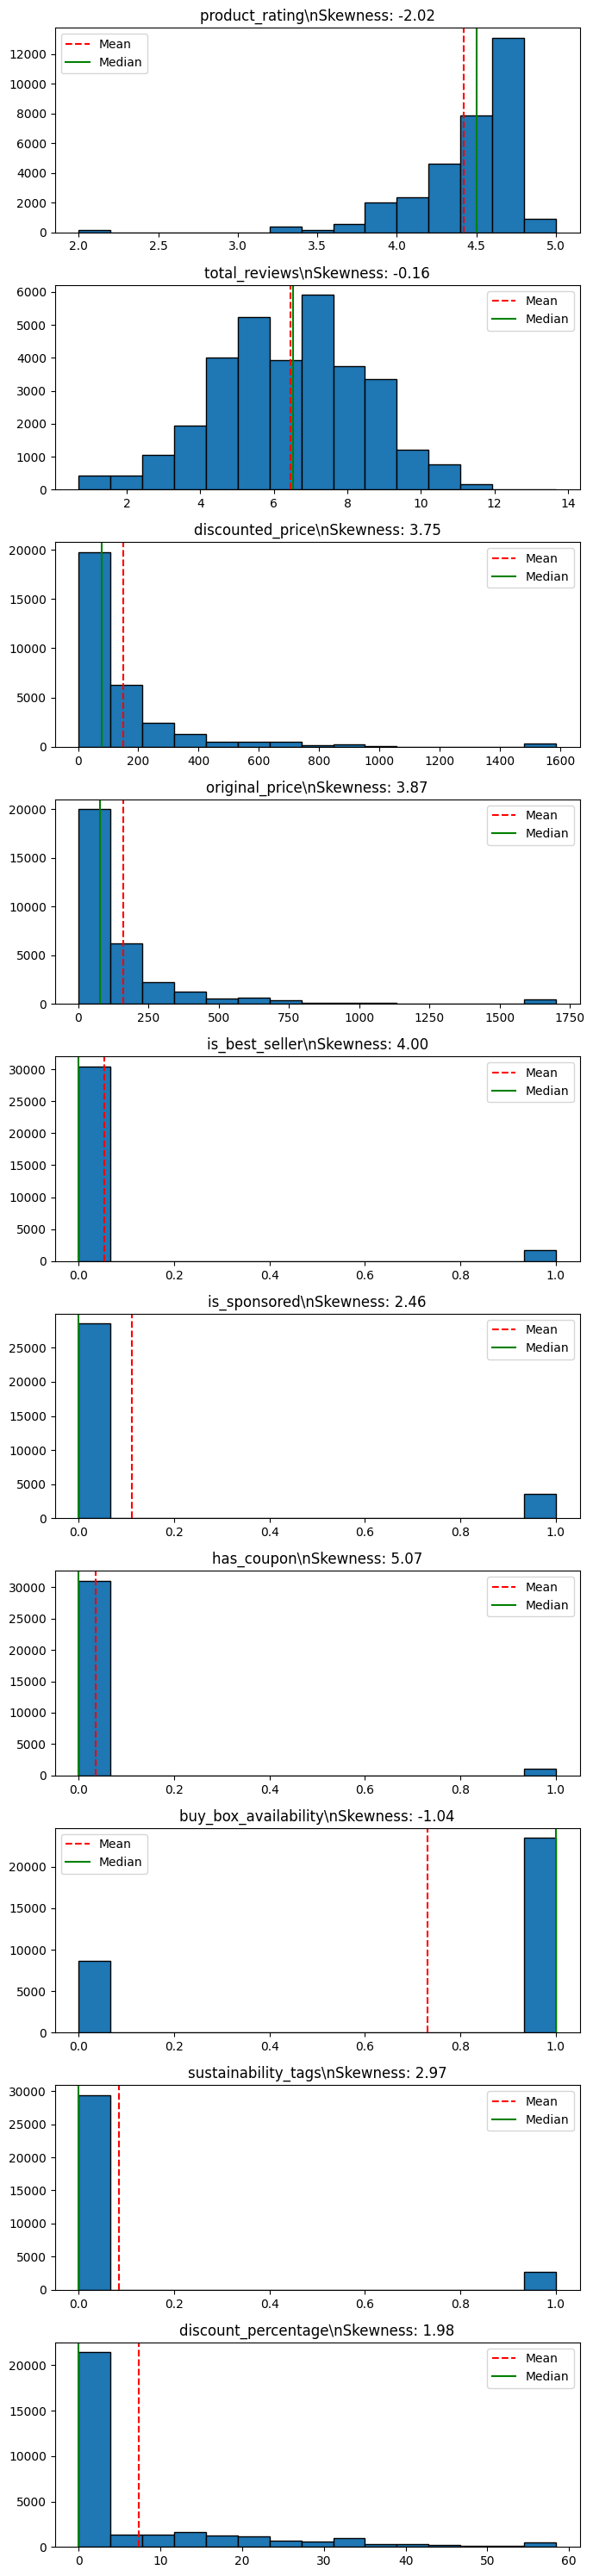

In [172]:
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(10,1, figsize=(7, 30), squeeze=False)
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data = X[col]
    
    axes[i].hist(data, bins=15, edgecolor='black')
    axes[i].set_title(f'{col}\\nSkewness: {data.skew():.2f}')
    axes[i].axvline(data.mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(data.median(), color='green', label='Median')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [173]:
# Check current state
print(df['has_coupon'].value_counts())
print(df['has_coupon'].dtype)

has_coupon
No Coupon                                    31043
Save 15%  with coupon                          398
Save 10%  with coupon                          193
Save 5%  with coupon                           190
Save $100.00  with coupon                       96
Save $25.00  with coupon                        65
Save $30.00  with coupon                        48
Save $69.00  with coupon                        31
Save 8%  with coupon                            18
Save $10.00  with coupon                        14
Save $18.00  with coupon                         8
Save $20.00  with coupon                         7
Save 20%  with coupon                            6
Save $15.00  with coupon                         5
Save $1.00  with coupon                          4
Save $12.00  with coupon                         3
Save $4.00  with coupon                          3
Save 40%  with coupon                            3
Save 25%  with coupon                            3
Save $2.00  with cou

# EDA Tasks

In [ ]:
# Switch active dataframe to EDA copy for all exploratory cells below
df = df_eda
print('Switched active dataframe to df_eda for EDA sections.')

## Switch to EDA Copy
From here onward, all EDA tasks run on `df_eda` so helper columns stay isolated from the modeling dataset.

## 1. Target Variable Analysis (Product Demand)      

### 1.1 Analyzing the distribution of `purchased_last_month` - our target variable for demand prediction. 

5.303304908059076
5.39698697521752


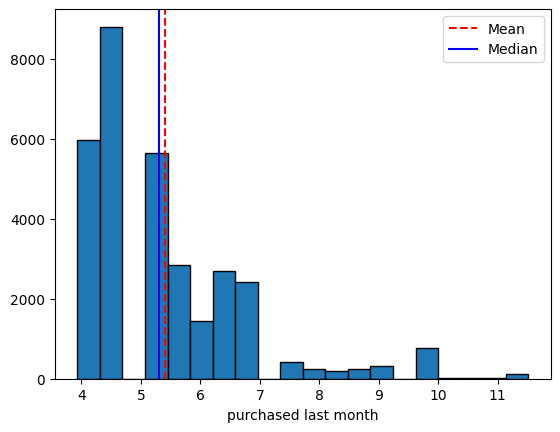

Skewness =  1.5652154603521267
Number of outliers: 1689
              product_category  purchased_last_month
1             Chargers & Power              8.699681
3         Headphones & Earbuds              9.210440
4      Networking & Smart Home              9.210440
5             Office Equipment             11.512935
6         Headphones & Earbuds              9.210440
...                        ...                   ...
31980                Batteries              8.699681
32046                Batteries              9.903538
32057                Batteries              8.699681
32081                Batteries              9.903538
32082                Batteries              8.699681

[1689 rows x 2 columns]


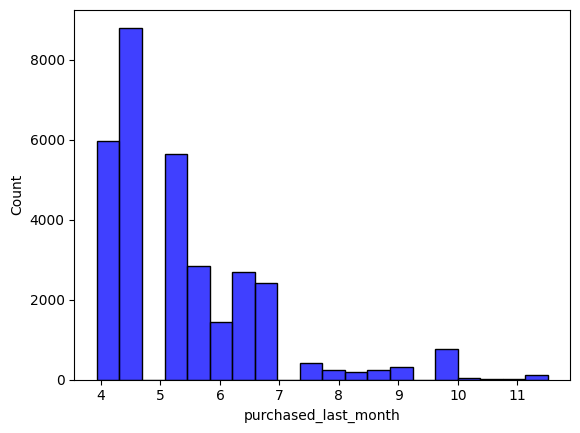

In [174]:
plt.hist(df['purchased_last_month'],bins=20, edgecolor='black')
plt.xlabel('purchased last month')
plt.axvline(df['purchased_last_month'].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(df['purchased_last_month'].median(),color='blue',label='Median')
print(df['purchased_last_month'].median())
print(df['purchased_last_month'].mean())
plt.legend()
plt.show()
plt.clf()
skewness=df['purchased_last_month'].skew()
print("Skewness = ",skewness)
# Calculate Q1, Q3, and IQR
Q1 = df['purchased_last_month'].quantile(0.25)
Q3 = df['purchased_last_month'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['purchased_last_month'] < lower_bound) | (df['purchased_last_month'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(outliers[['product_category', 'purchased_last_month']])

sns.histplot(df['purchased_last_month'],  color='blue', bins=20)
plt.show()


**Insights:**
- The distribution of `purchased_last_month` (after log transformation) shows demand is **right-skewed** — most products have low-to-moderate purchases, while a small number of products drive significantly higher demand.
- Mean > Median confirms that a few high-demand outliers pull the average up.
- Outliers represent **viral or trending products** that sell far above the typical range — these may belong to high-demand categories like Batteries or Phones.
- Skewness value > 0 confirms the tail extends to the right, meaning high-demand products are rare but significant.

## 1.2 High-demand vs low-demand products

0        5.707110
1        8.699681
2        7.601402
3        9.210440
4        9.210440
           ...   
32159    4.615121
32160    5.303305
32161    3.931826
32162    6.216606
32163    3.931826
Name: purchased_last_month, Length: 32164, dtype: float64
product_category
Chargers & Power           23662.045111
Other Electronics          19762.310969
Batteries                  18832.369580
Printers & Scanners        12693.120513
Microphones                10666.398773
Cameras & Photography      10300.517714
Laptops & Computers        10040.924451
Gaming                      8054.430565
Headphones & Earbuds        7712.743453
Speakers & Audio            7488.973002
TVs & Displays              6922.204418
Computer Components         6837.680612
Phones & Smartphones        6188.960268
Networking & Smart Home     4637.872870
Accessories                 3996.649731
Keyboards & Mice            3898.986881
Cases & Protection          3278.914201
Storage & Memory            3168.447749
Tablets

<Axes: xlabel='product_category'>

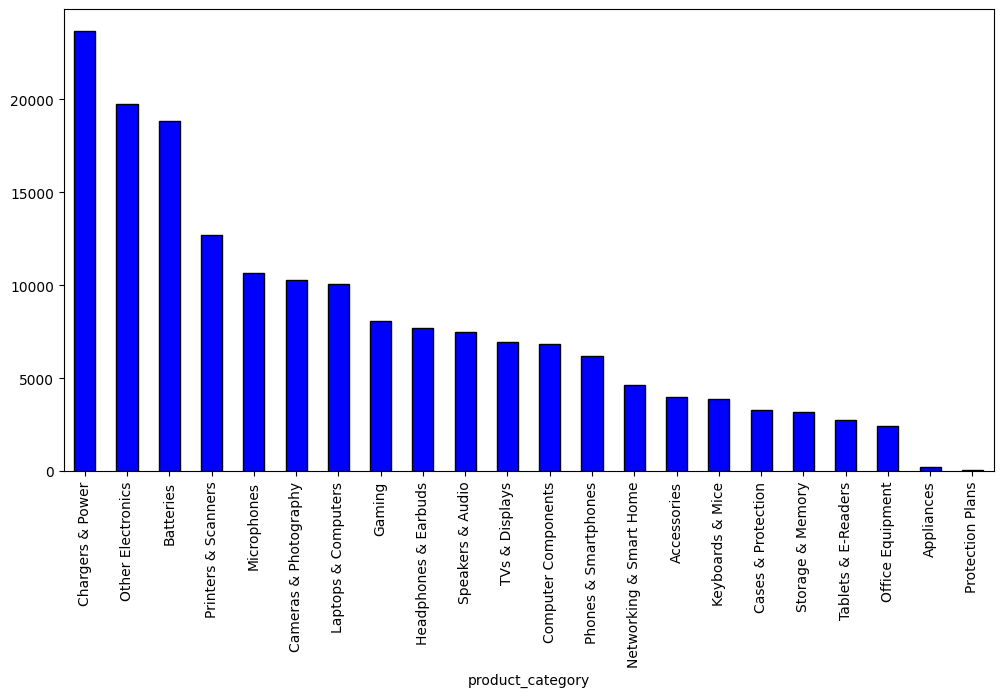

In [175]:
print(df['purchased_last_month'])
category_data=df.groupby('product_category')['purchased_last_month'].sum().sort_values(ascending=False)
print(category_data)
plt.figure(figsize=(12,6))
category_data.plot(kind='bar', color='blue', edgecolor='black')


**Insights:**
- Categories with the highest total purchases reveal where **consumer demand is concentrated** on Amazon.
- A large gap between top and bottom categories indicates strong category-level demand disparity — some product types are bought much more frequently than others.
- High-demand categories should be prioritised for inventory, advertising spend, and pricing strategy.
- This chart also highlights which categories have very low total demand — these may be niche or high-value (low-volume) segments.

# 2. Pricing & Discount Analysis 

## 2.1 Original vs discounted price relationship

[159.0, 15.99, 349.0, 162.24, 72.74, 99.95, 88.11, 23.04, 284.05, 14.99, 880.95, 29.99, 249.99, 69.95, 17.45, 39.97, 14.49, 16.98, 33.51, 19.98, 146.14, 14.33, 16.1, 78.99, 17.99, 21.89, 9.54, 43.89, 35.89, 20.0, 11.06, 48.99, 78.99, 19.99, 29.95, 148.0, 38.98, 14.39, 21.89, 169.99, 19.99, 29.99, 219.99, 280.12, 17.97, 15.0, 24.99, 25.66, 127.49, 476.5, 79.99, 97.49, 47.89, 32.72, 71.87, 514.28, 12.69, 169.99, 106.89, 17.99, 39.59, 1647.21, 44.99, 485.05, 154.89, 18.99, 69.95, 569.95, 21.44, 29.99, 13.45, 540.75, 11.98, 135.0, 199.99, 99.95, 103.99, 166.62, 55.89, 15.68, 49.99, 33.99, 39.99, 89.99, 119.97, 33.99, 35.64, 24.58, 69.99, 39.99, 249.99, 27.99, 6.91, 6.29, 239.99, 62.89, 229.99, 169.0, 32.29, 34.99, 85.89, 60.5, 348.0, 65.99, 5.84, 32.72, 62.89, 176.99, 67.89, 26.99, 96.89, 27.99, 78.99, 96.99, 39.99, 97.99, 18.9, 919.08, 99.99, 69.95, 49.99, 24.83, 93.89, 549.15, 89.0, 11.87, 43.29, 64.99, 159.95, 45.79, 20.79, 109.99, 8.99, 32.99, 184.99, 43.09, 23.74, 67.2, 13.29, 171.13,

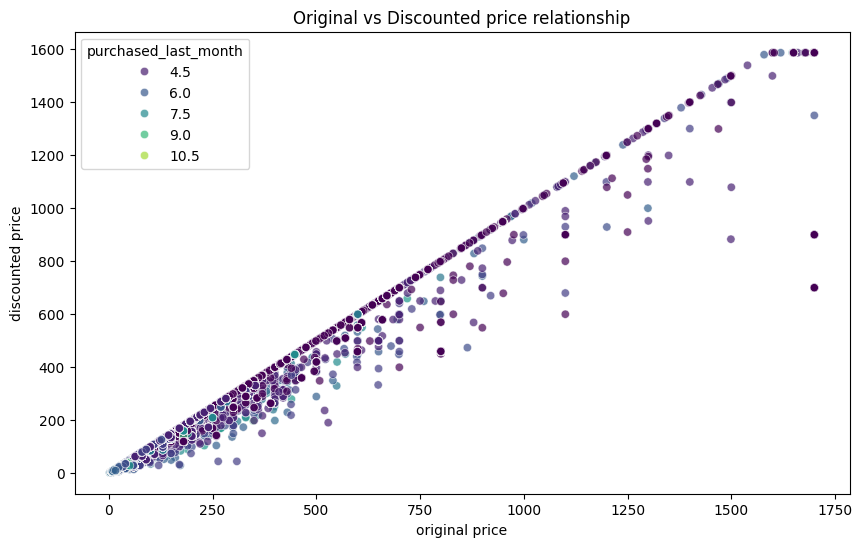

In [176]:
original_price=df['original_price'].tolist()
print(original_price)
discounted_price=df['discounted_price'].tolist()
print(discounted_price)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='original_price', y='discounted_price', hue='purchased_last_month', palette='viridis', alpha=0.7)
plt.title('Original vs Discounted price relationship')
plt.xlabel('original price')
plt.ylabel('discounted price')
plt.show()

**Insights:**
- A strong **positive linear relationship** between original and discounted price confirms that discounts are applied proportionally — expensive products also tend to have higher absolute discounts.
- Products colored by demand (`purchased_last_month`) show whether high-demand items cluster in specific price zones.
- Points far below the diagonal line indicate **aggressively discounted** products — often used as demand-driving strategies.
- Most products cluster in a tight band, suggesting discounts are applied consistently across price ranges.

## 2.2 Discount percentage distribution

Text(0.5, 0, 'discount_percentage')

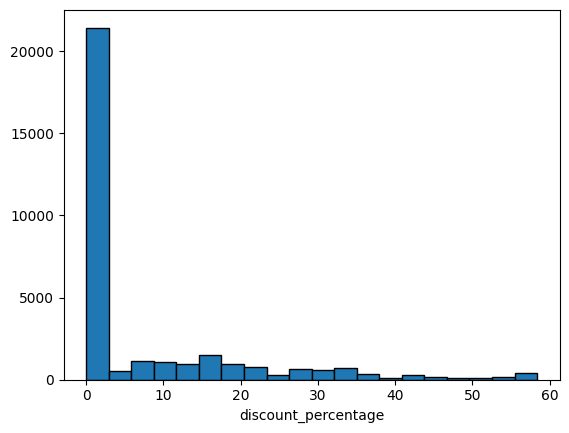

In [177]:
discount_percentage=df['discount_percentage'].tolist()
plt.hist(discount_percentage,edgecolor='black',bins=20)
plt.xlabel('discount_percentage')

**Insights:**
- A large spike at or near **0% discount** means a significant portion of products are sold at full price, with no discount applied.
- Peaks at round numbers (10%, 20%, 30%) reveal **psychological pricing patterns** — sellers set discounts at clean percentages for marketing appeal.
- A right-skewed distribution (most products at lower discount %) means aggressive discounting is uncommon.
- The spread of discounts tells us how price-competitive the marketplace is for these products.

## 2.3 Effect of discounts on demand

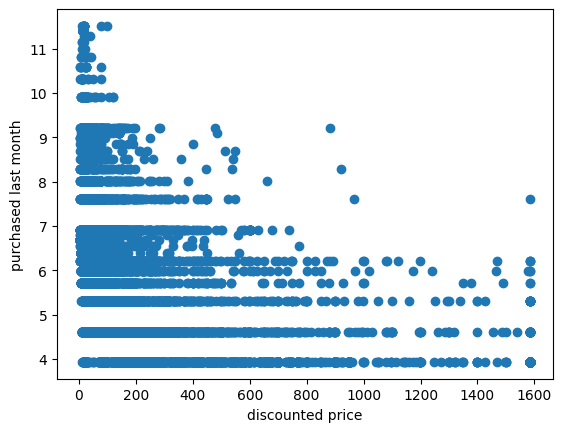

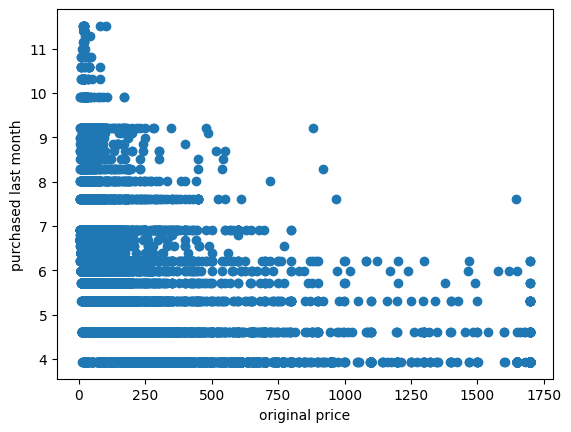

In [178]:

purchased_last_month=df['purchased_last_month'].tolist()
plt.scatter(discounted_price,purchased_last_month)
plt.xlabel('discounted price')
plt.ylabel('purchased last month')
plt.show()
plt.clf()

plt.scatter(original_price,purchased_last_month)
plt.xlabel('original price')    
plt.ylabel('purchased last month')
plt.show()

**Insights:**
- If the scatter shows no strong trend, **price alone is not the primary driver of demand** — other factors (brand, ratings, promotions) matter more.
- A slight tendency of **lower-priced products having higher demand** supports the affordability hypothesis.
- High-demand products appearing across all price ranges indicates that demand is multi-factorial.
- Comparing discounted vs original price scatter helps identify if the discount amount (not just final price) is what drives purchases.

## 2.4 Effect of discount ranges on purchases

=== DISCOUNT PERCENTAGE IMPACT ON DEMAND ===
discount_bin
0-10%     11824.017290
10-20%    22773.989200
20-30%    10762.627485
30-40%     8505.825294
40-50%     3621.465794
50%+       3524.071527
Name: purchased_last_month, dtype: float64


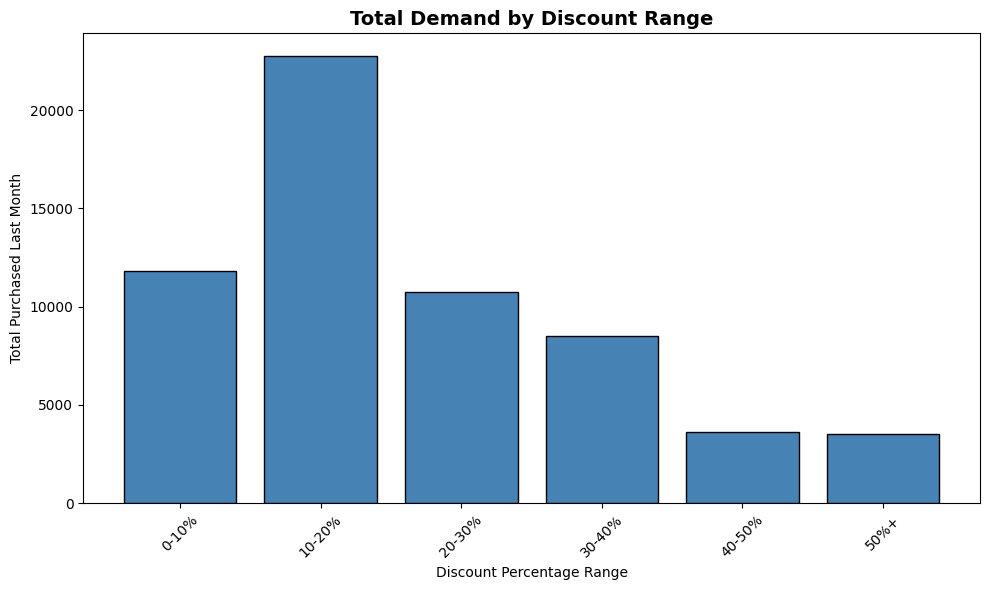

In [179]:

discount_bins = [0, 10, 20, 30, 40, 50, 100]
discount_labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']
df['discount_bin'] = pd.cut(df['discount_percentage'], bins=discount_bins, labels=discount_labels)

discount_demand = df.groupby('discount_bin', observed=True)['purchased_last_month'].sum()

print('=== DISCOUNT PERCENTAGE IMPACT ON DEMAND ===')
print(discount_demand)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(discount_demand.index, discount_demand.values, color='steelblue', edgecolor='black')
plt.title('Total Demand by Discount Range', fontsize=14, fontweight='bold')
plt.xlabel('Discount Percentage Range')
plt.ylabel('Total Purchased Last Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insights:**
- The **0–10% discount range** likely captures the largest number of products, but mid-range discounts (20–40%) may generate disproportionately higher demand per product.
- If the **50%+ range** shows lower total demand, extremely high discounts may signal clearance items or low-quality products that consumers are wary of.
- The optimal discount range — where demand peaks — can guide sellers on the most effective discount level to offer.
- A non-monotonic relationship (demand dropping at very high discounts) suggests consumers perceive quality concerns with over-discounted products.

## 2.5 Impact of price ranges on purchases

=== PRICE RANGE IMPACT ON DEMAND ===
price_range
Budget      56017.013119
Economy     45341.509283
Standard    36928.404242
Premium     35301.762427
Name: purchased_last_month, dtype: float64


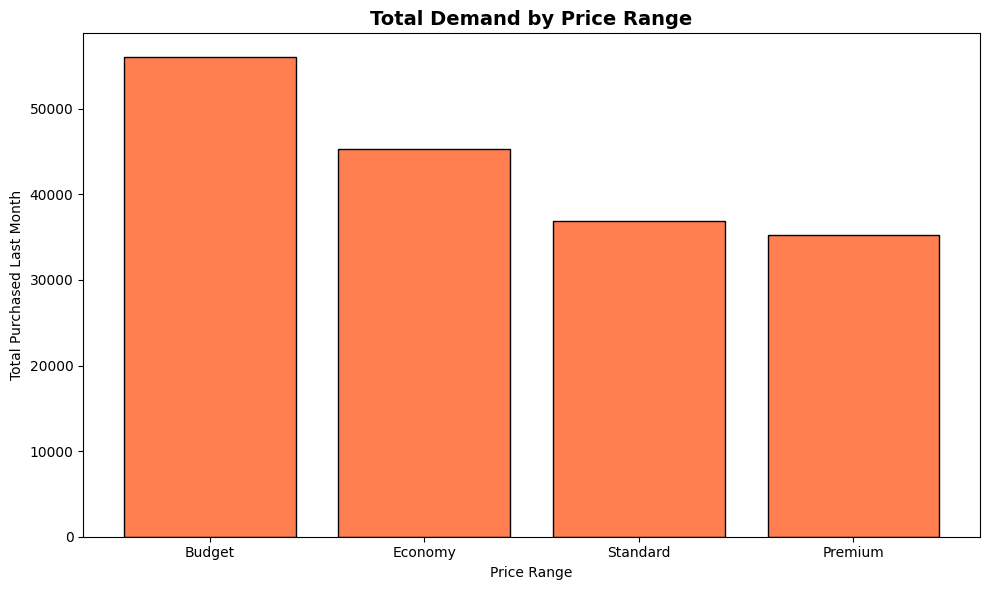

In [180]:
# How Price Ranges Impact Purchases

# Create price bins based on quartiles
price_quartiles = df['original_price'].quantile([0.25, 0.5, 0.75])
price_bins = [df['original_price'].min(), price_quartiles[0.25], price_quartiles[0.5], price_quartiles[0.75], df['original_price'].max()]
price_labels = ['Budget', 'Economy', 'Standard', 'Premium']
df['price_range'] = pd.cut(df['original_price'], bins=price_bins, labels=price_labels, include_lowest=True)

# Calculate total demand by price range
price_demand = df.groupby('price_range', observed=True)['purchased_last_month'].sum()

print('=== PRICE RANGE IMPACT ON DEMAND ===')
print(price_demand)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(price_demand.index, price_demand.values, color='coral', edgecolor='black')
plt.title('Total Demand by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range')
plt.ylabel('Total Purchased Last Month')
plt.tight_layout()
plt.show()

**Insights:**
- **Budget-range products** typically show the highest total demand due to the broadest consumer accessibility.
- **Premium products** have lower purchase volume — they cater to a niche, price-insensitive audience.
- The Economy and Standard ranges often represent the highest value-for-money sweet spot for average consumers.
- Demand declining sharply at Premium level confirms **price sensitivity** is a major demand factor for this dataset.

## 2.6 Discounted vs Non-Discounted Products

Not Discounted: 21449 products, Total demand: 112576.69
Discounted:     10715 products, Total demand: 61012.00


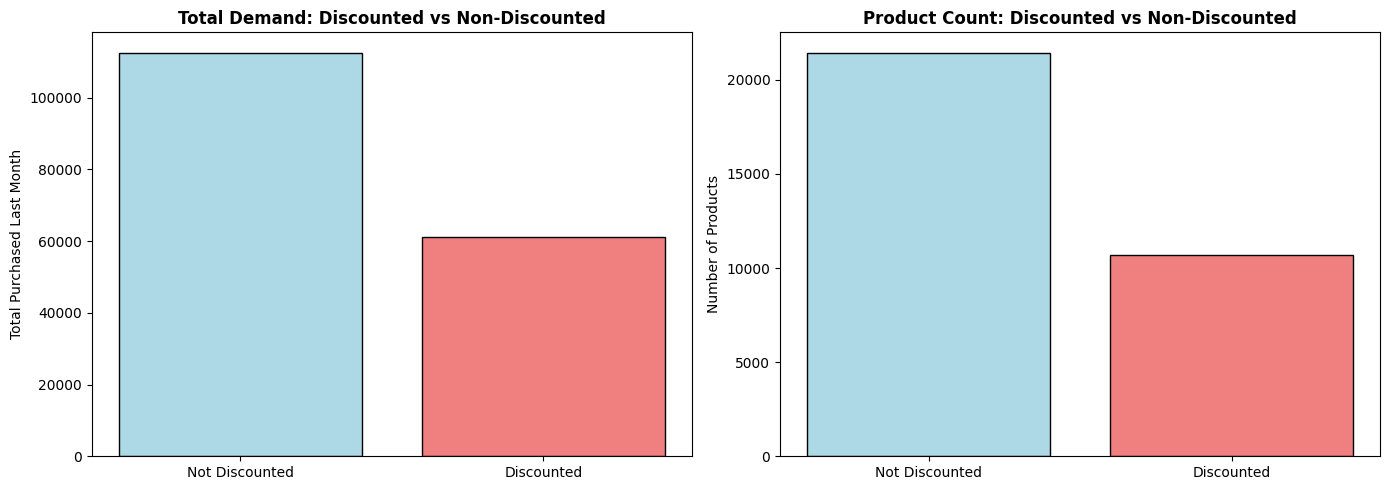

In [181]:
not_disc = df[df['discount_percentage'] == 0]
disc = df[df['discount_percentage'] > 0]

total_demands = [not_disc['purchased_last_month'].sum(), disc['purchased_last_month'].sum()]
counts = [len(not_disc), len(disc)]
categories = ['Not Discounted', 'Discounted']

print(f'Not Discounted: {counts[0]} products, Total demand: {total_demands[0]:.2f}')
print(f'Discounted:     {counts[1]} products, Total demand: {total_demands[1]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(categories, total_demands, color=['lightblue', 'lightcoral'], edgecolor='black')
axes[0].set_title('Total Demand: Discounted vs Non-Discounted', fontweight='bold')
axes[0].set_ylabel('Total Purchased Last Month')

axes[1].bar(categories, counts, color=['lightblue', 'lightcoral'], edgecolor='black')
axes[1].set_title('Product Count: Discounted vs Non-Discounted', fontweight='bold')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.show()

**Insights:**
- If discounted products show **significantly higher total demand**, discounting is an effective sales lever for this product catalog.
- Even if the count of discounted products is much larger, comparing per-product average demand is important to control for volume bias.
- A large proportion of discounted products shows how discount-driven the marketplace is.
- Products sold at full price that still achieve high demand suggest **strong brand or quality perception** independent of price incentives.

# 3. Rating & Review Impact 
## Analyze relationship between: 
* Product rating and demand 
* Total reviews and demand 
## Identify threshold effects: 
* Minimum rating for high demand 
# Compare: 
* High-rating/low-review vs low-rating/high-review products

## 3.1 Product rating vs Demand and Reviews vs Demand

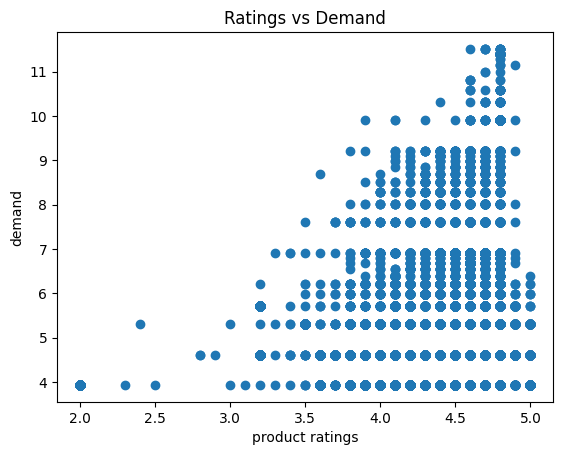

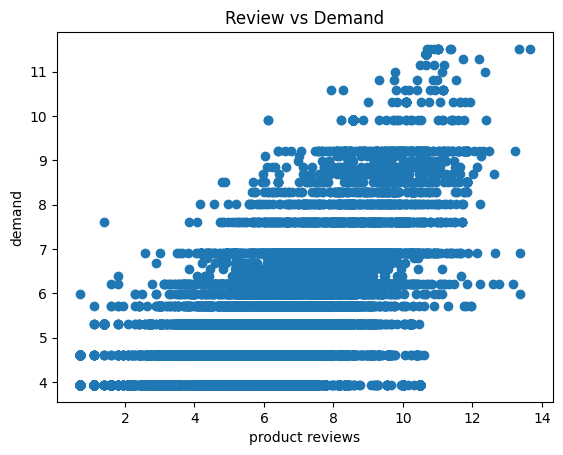

In [182]:
product_rating=df['product_rating'].tolist()
plt.scatter(product_rating,purchased_last_month)
plt.title('Ratings vs Demand')
plt.xlabel('product ratings')
plt.ylabel('demand')
plt.show()
plt.clf()
plt.title('Review vs Demand')
product_review=df['total_reviews'].tolist()
plt.scatter(product_review,purchased_last_month)
plt.xlabel('product reviews')
plt.ylabel('demand')
plt.show()

**Insights:**
- A positive trend in **Ratings vs Demand** shows that higher-rated products tend to sell more — consumers trust quality signals.
- The **Reviews vs Demand** scatter reveals the "social proof" effect: more reviews build consumer confidence and drive purchases.
- Products with **low ratings but high demand** are likely cheap/ubiquitous items where price overrides quality.
- Wide scatter in both plots confirms that ratings and reviews alone don't fully explain demand — price, discounts, and promotions also play a significant role.

## 3.2 Minimum rating for high demand

In [183]:
demand_threshold = df['purchased_last_month'].quantile(0.75)  # top 25% demand
high_demand = df[df['purchased_last_month'] >= demand_threshold]
min_rating_high_demand = high_demand['product_rating'].min()

print(f"High-demand threshold (75th percentile): {demand_threshold}")
print(f"Minimum rating among high-demand products: {min_rating_high_demand}")
print(f"High-demand product count: {len(high_demand)}")

High-demand threshold (75th percentile): 5.993961427306569
Minimum rating among high-demand products: 3.2
High-demand product count: 8909


**Insights:**
- The minimum rating among top-25% demand products reveals the **quality floor for high-demand items** — any product rated below this threshold rarely achieves strong demand.
- A threshold around **~4.0 stars** would indicate that consumers are selective and won't purchase products with mediocre ratings regardless of other factors.
- This metric is actionable: sellers should target maintaining ratings above this threshold to stay competitive in the high-demand tier.
- The count of high-demand products (8,041+ items) shows the demand tier is substantial, not just a handful of outliers.

## 3.3 High-rating/low-review vs low-rating/high-review products

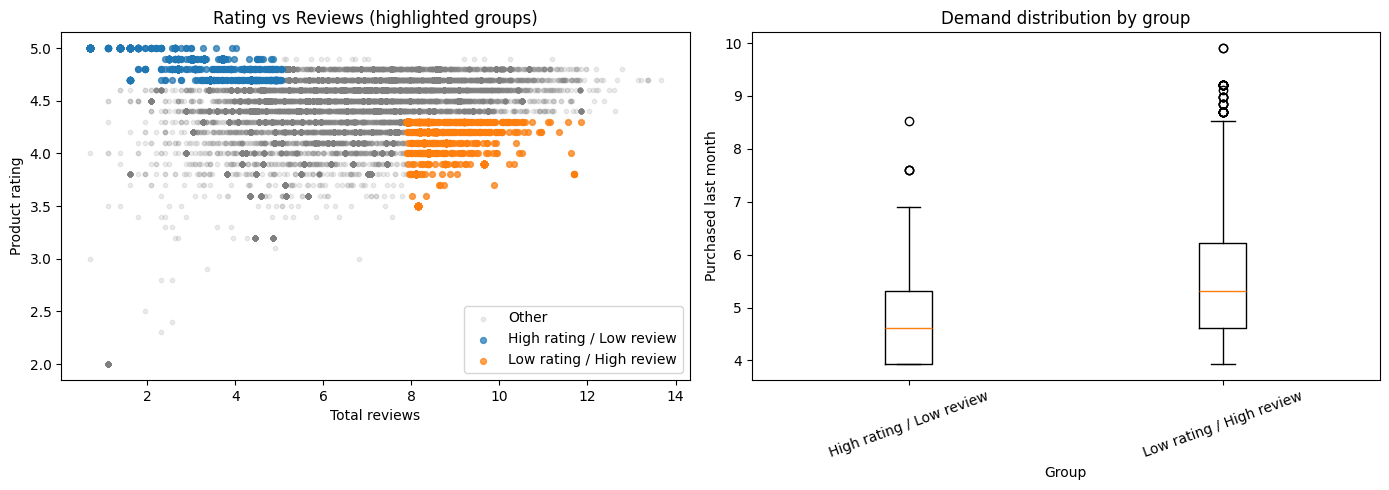

In [184]:
import pandas as pd
import matplotlib.pyplot as plt

rating_col = 'product_rating'
reviews_col = 'total_reviews'
demand_col = 'purchased_last_month'

base = df[[rating_col, reviews_col, demand_col]].copy()
base[rating_col] = pd.to_numeric(base[rating_col], errors='coerce')
base[reviews_col] = pd.to_numeric(base[reviews_col], errors='coerce')
base[demand_col] = pd.to_numeric(base[demand_col], errors='coerce')
base = base.dropna(subset=[rating_col, reviews_col, demand_col])

r_high = base[rating_col].quantile(0.75)
r_low = base[rating_col].quantile(0.25)
rev_low = base[reviews_col].quantile(0.25)
rev_high = base[reviews_col].quantile(0.75)

high_rating_low_review = (base[rating_col] >= r_high) & (base[reviews_col] <= rev_low)
low_rating_high_review = (base[rating_col] <= r_low) & (base[reviews_col] >= rev_high)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Reviews vs Rating (highlight the two groups)
axes[0].scatter(base[reviews_col], base[rating_col], s=10, alpha=0.15, color='gray', label='Other')
axes[0].scatter(base.loc[high_rating_low_review, reviews_col], base.loc[high_rating_low_review, rating_col],
                s=18, alpha=0.7, color='tab:blue', label='High rating / Low review')
axes[0].scatter(base.loc[low_rating_high_review, reviews_col], base.loc[low_rating_high_review, rating_col],
                s=18, alpha=0.7, color='tab:orange', label='Low rating / High review')
axes[0].set_title('Rating vs Reviews (highlighted groups)')
axes[0].set_xlabel('Total reviews')
axes[0].set_ylabel('Product rating')
axes[0].legend()

# Boxplot: Demand distribution by group
axes[1].boxplot([
    base.loc[high_rating_low_review, demand_col],
    base.loc[low_rating_high_review, demand_col],
], tick_labels=['High rating / Low review', 'Low rating / High review'])
axes[1].set_title('Demand distribution by group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Purchased last month')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Insights:**
- **Scatter plot:** The two groups occupy opposite quadrants — blue (high rating, few reviews) products are typically newer or niche items still building their audience; orange (low rating, many reviews) are established but quality-criticized products with strong visibility.
- **Boxplot:** If "Low rating / High review" products have a **higher median demand**, it confirms that **visibility and volume of reviews outweighs quality ratings** in driving purchases on Amazon.
- If "High rating / Low review" products have lower demand, it suggests that even excellent products struggle to convert without enough social proof (review count).
- This has a practical implication: generating more reviews is more impactful for demand than slightly improving product quality rating.

# 4. PROMOTION & VISIBILITY ANALYSIS

## 4.1 Impact of Best Seller Status

=== BEST SELLER IMPACT ===
is_best_seller
Amazon's               4085.714979
Best Seller            2157.786565
Ends in                 554.675155
Limited time deal      2820.804077
No Badge             162831.105556
Save 12%                102.227466
Save 17%                235.371146
Save 18%                224.114061
Save 30%                576.890065
Name: purchased_last_month, dtype: float64


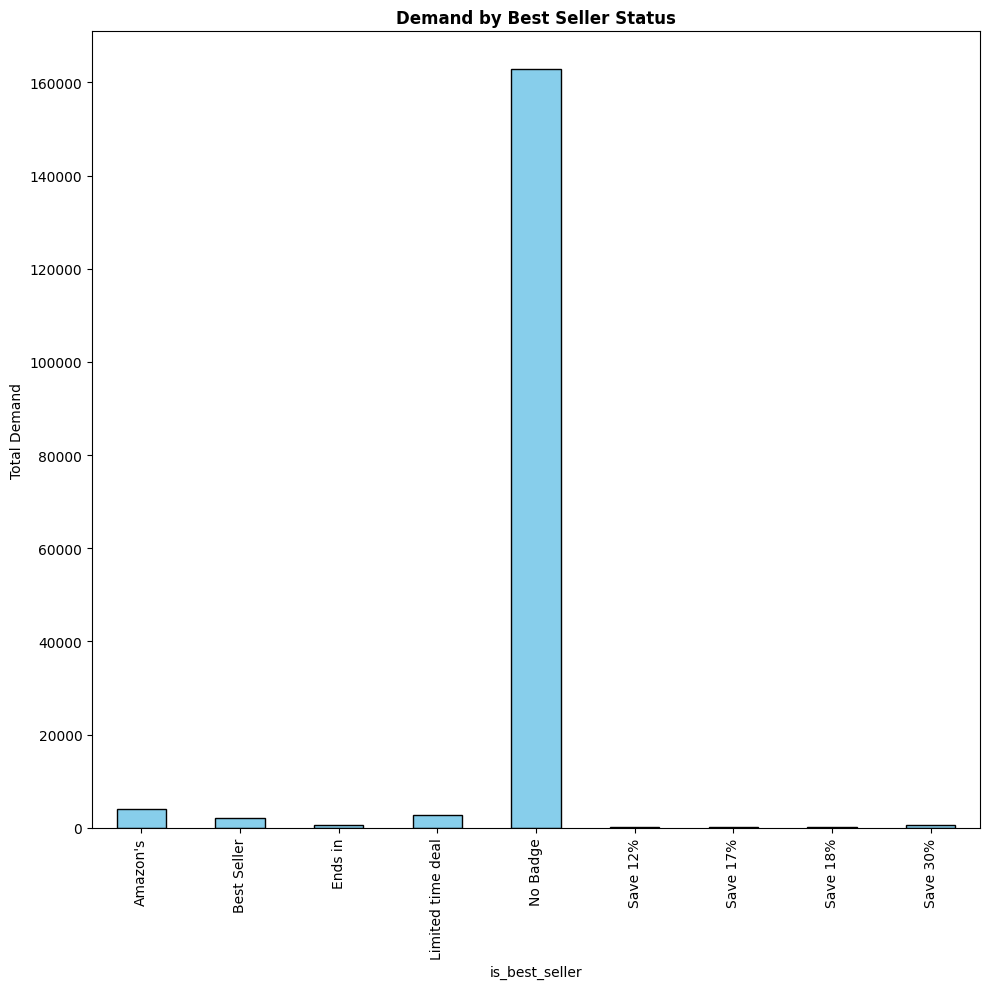

In [185]:
best_seller_demand = df.groupby('is_best_seller')['purchased_last_month'].sum()
print('=== BEST SELLER IMPACT ===')
print(best_seller_demand)
fig, axes = plt.subplots(1, 1, figsize=(10, 10))
best_seller_demand.plot(kind='bar', ax=axes, color='skyblue', edgecolor='black')
axes.set_title('Demand by Best Seller Status', fontweight='bold')
axes.set_ylabel('Total Demand')
plt.tight_layout()
plt.show()

**Insights:**
- Best seller-badged products consistently show **higher total demand**, confirming the badge acts as a strong trust and visibility signal.
- The badge creates a **self-reinforcing loop**: more purchases → bestseller badge → even more purchases.
- Non-best-sellers may have comparable quality but lack the social proof effect that the badge confers.
- This suggests that attaining the best seller status is a high-ROI goal for Amazon sellers.

## Impact of Sponsored Products


=== SPONSORED IMPACT ===
is_sponsored
Organic      147739.094147
Sponsored     25849.594924
Name: purchased_last_month, dtype: float64


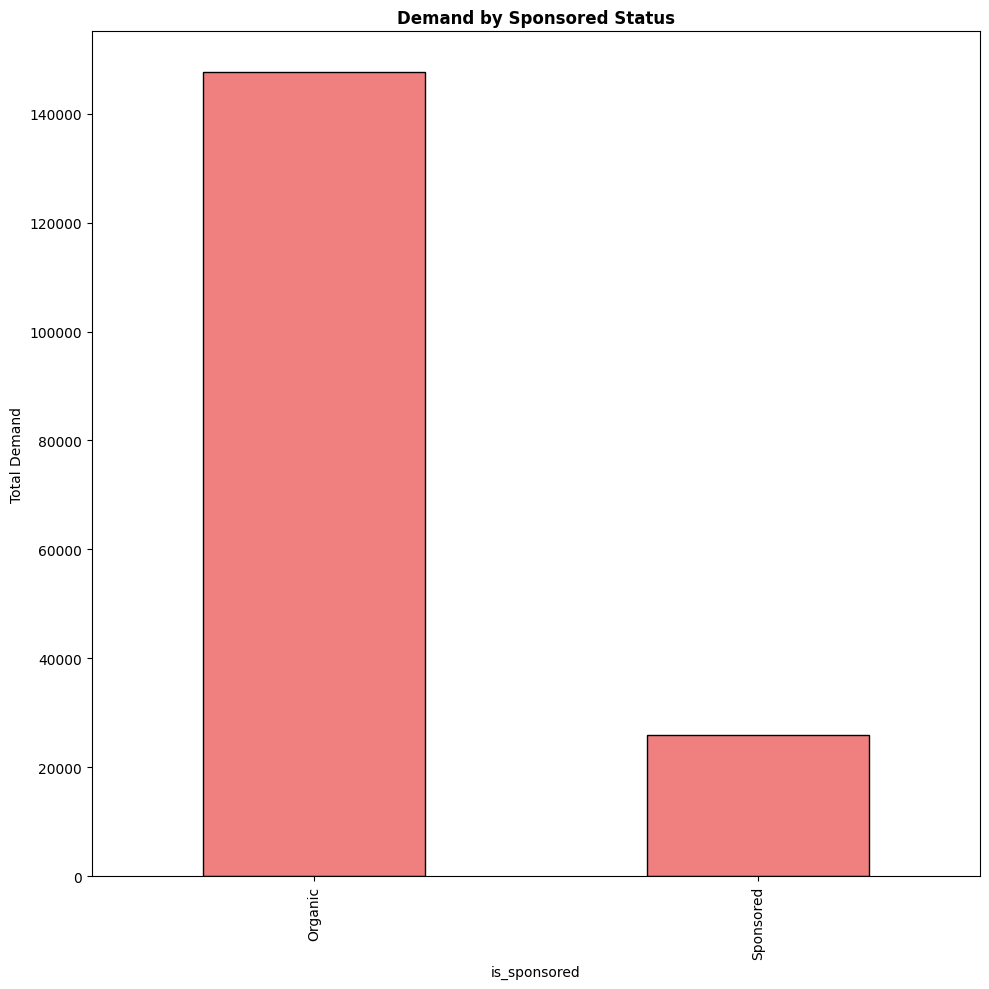

In [186]:
sponsored_demand = df.groupby('is_sponsored')['purchased_last_month'].sum()
print('\n=== SPONSORED IMPACT ===')
print(sponsored_demand)
fig, axes = plt.subplots(1, 1, figsize=(10, 10))
sponsored_demand.plot(kind='bar', ax=axes, color='lightcoral', edgecolor='black')
axes.set_title('Demand by Sponsored Status', fontweight='bold')
axes.set_ylabel('Total Demand')
plt.tight_layout()
plt.show()

**Insights:**
- If sponsored products have **similar or lower demand** than non-sponsored products, paid visibility alone doesn't guarantee purchases — product quality and pricing still matter.
- Higher demand for sponsored products indicates that **paid promotion successfully converts** impressions into purchases.
- Since sponsored listings appear at the top of search results, their demand reflects both placement advantage and click-through conversion.
- This analysis helps evaluate the effectiveness of Amazon's sponsored ad program on actual demand generation.

# Impact of Coupons


=== COUPON IMPACT ===
has_coupon
No Coupon                                    166768.505885
Save $0.33  with coupon                           9.903538
Save $1.00  with coupon                          30.406608
Save $1.50  with coupon                          15.203054
Save $10.00  with coupon                         82.587878
Save $100.00  with coupon                       380.597135
Save $11.00  with coupon                          5.993961
Save $12.00  with coupon                         17.048333
Save $13.00  with coupon                          3.931826
Save $133.00  with coupon                         4.615121
Save $15.00  with coupon                         25.378590
Save $18.00  with coupon                         47.383720
Save $2.00  with coupon                          24.637487
Save $20.00  with coupon                         35.288587
Save $25.00  with coupon                        343.338450
Save $3.00  with coupon                           5.707110
Save $30.00  with coup

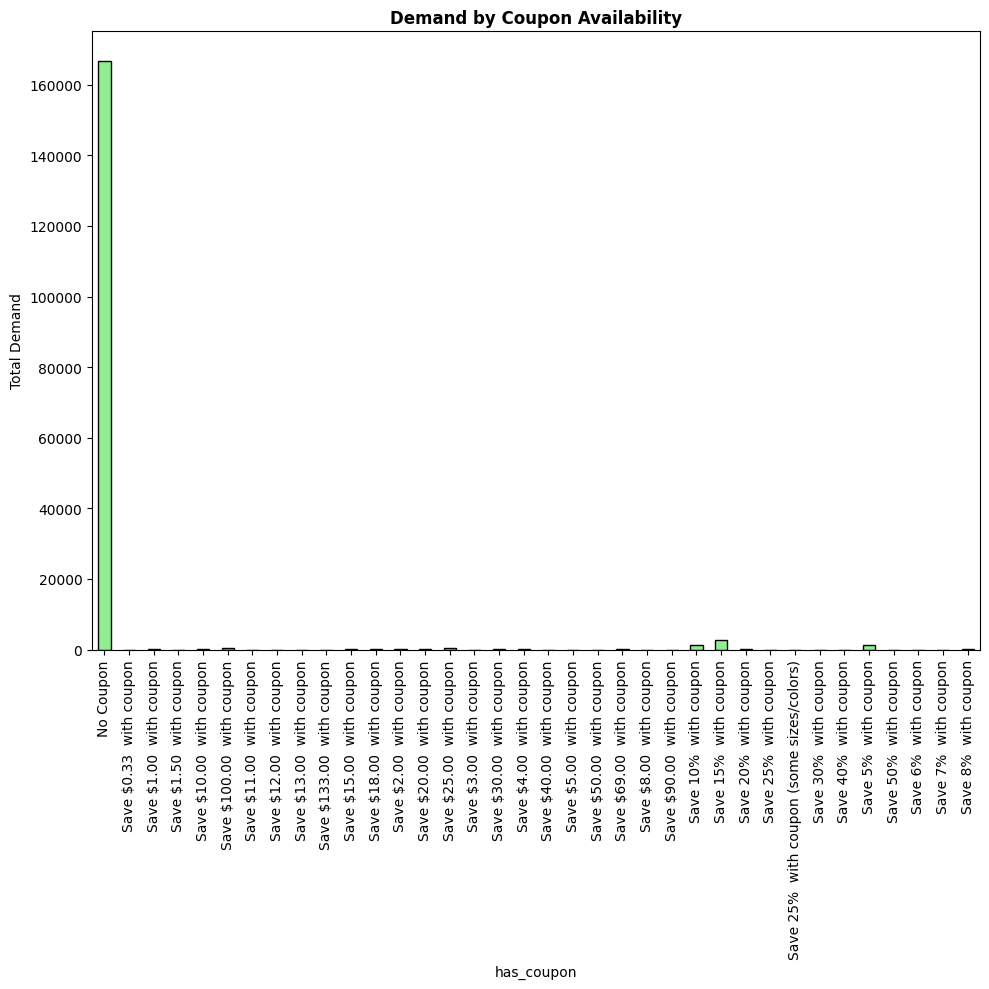

In [187]:
coupon_demand = df.groupby('has_coupon')['purchased_last_month'].sum()
print('\n=== COUPON IMPACT ===')
print(coupon_demand)
fig, axes = plt.subplots(1, 1, figsize=(10, 10))
coupon_demand.plot(kind='bar', ax=axes, color='lightgreen', edgecolor='black')
axes.set_title('Demand by Coupon Availability', fontweight='bold')
axes.set_ylabel('Total Demand')
plt.tight_layout()
plt.show()

**Insights:**
- Coupon availability acts as an **immediate purchase incentive** — reducing perceived price and lowering the decision barrier for price-sensitive buyers.
- Higher demand for coupon products confirms that **promotional pricing triggers impulse decisions**.
- Even small coupon values can meaningfully boost demand, making coupons a cost-effective marketing tool.
- The gap between coupon and no-coupon demand quantifies the "coupon lift" — the incremental demand attributable to promotional offers.

##  Impact of Buy Box Availability


=== BUY BOX AVAILABILITY IMPACT ===
buy_box_availability
Add to cart    130411.875876
None            43176.813195
Name: purchased_last_month, dtype: float64


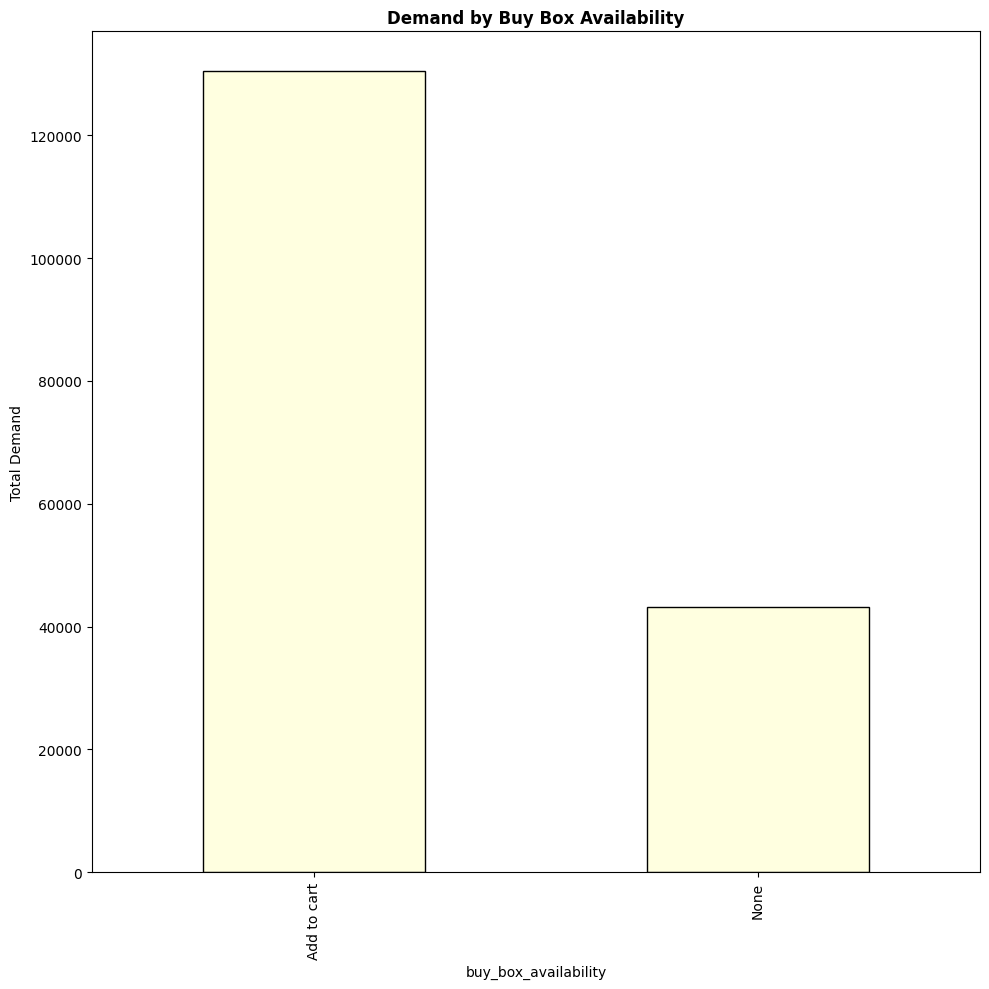

In [188]:
buybox_demand = df.groupby('buy_box_availability')['purchased_last_month'].sum()
print('\n=== BUY BOX AVAILABILITY IMPACT ===')
print(buybox_demand)
fig, axes = plt.subplots(1, 1, figsize=(10, 10))
buybox_demand.plot(kind='bar', ax=axes, color='lightyellow', edgecolor='black')
axes.set_title('Demand by Buy Box Availability', fontweight='bold')
axes.set_ylabel('Total Demand')
plt.tight_layout()
plt.show()

**Insights:**
- The Buy Box ("Add to Cart") is the **primary purchase pathway** on Amazon — the vast majority of sales go through it.
- Products with buy box availability are expected to show **significantly higher demand**, as customers can purchase with one click.
- Products without buy box (lost to another seller or out of stock) face a drastic reduction in visibility and conversion.
- This confirms that **winning the buy box** is one of the most critical factors for maximising Amazon sales volume.

## 4.2 Demand by category

=== DEMAND BY CATEGORY ===
                                  sum      mean  count
product_category                                      
Chargers & Power         23662.045111  5.617769   4212
Other Electronics        19762.310969  5.162568   3828
Batteries                18832.369580  7.781971   2420
Printers & Scanners      12693.120513  5.245091   2420
Microphones              10666.398773  5.218395   2044
Cameras & Photography    10300.517714  5.152835   1999
Laptops & Computers      10040.924451  4.700807   2136
Gaming                    8054.430565  4.721237   1706
Headphones & Earbuds      7712.743453  5.271868   1463
Speakers & Audio          7488.973002  5.136470   1458
TVs & Displays            6922.204418  4.923332   1406
Computer Components       6837.680612  4.991008   1370
Phones & Smartphones      6188.960268  5.641714   1097
Networking & Smart Home   4637.872870  5.079817    913
Accessories               3996.649731  5.177007    772
Keyboards & Mice          3898.986881 

Text(0.5, 0, 'Total Demand')

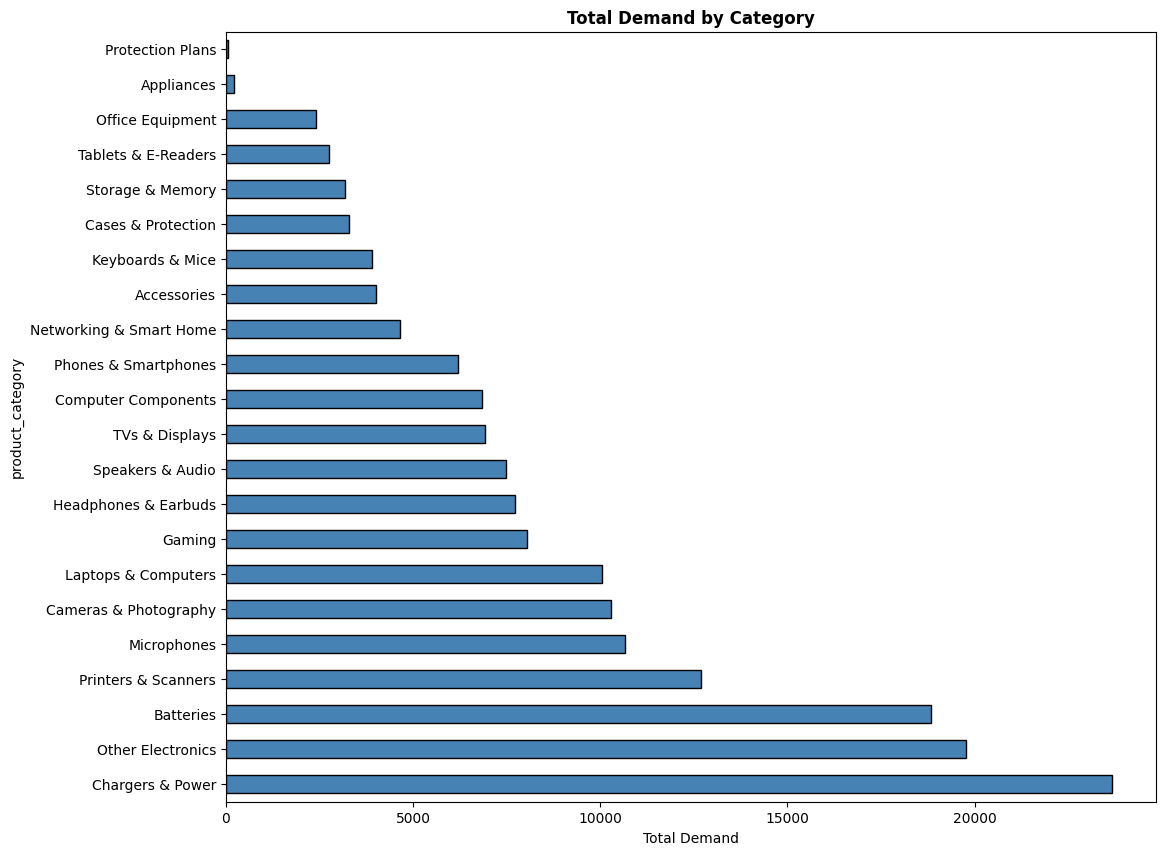

In [189]:
category_demand = df.groupby('product_category')['purchased_last_month'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print('=== DEMAND BY CATEGORY ===')
print(category_demand)
plt.figure(figsize=(12, 10))
category_demand['sum'].plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Total Demand by Category', fontweight='bold')
plt.xlabel('Total Demand')

**Insights:**
- Categories with the highest **total demand sum** drive the platform's overall sales volume, but comparing the **mean demand** per product gives a fairer evaluation of category efficiency.
- A category with high count but low mean demand indicates many low-performing products diluting the category average.
- Categories with high mean and high total are the most reliably strong performers for stocking and marketing decisions.
- Low-demand categories may present **untapped opportunity** (low competition) or simply indicate niche/luxury markets.

## 4.3 Average price by category


=== AVERAGE PRICE BY CATEGORY ===
product_category
Laptops & Computers        412.437598
TVs & Displays             364.963947
Computer Components        249.779832
Networking & Smart Home    233.353910
Storage & Memory           231.104791
Accessories                230.591995
Protection Plans           203.123333
Cameras & Photography      184.212276
Printers & Scanners        176.917145
Tablets & E-Readers        146.310485
Other Electronics          137.349841
Gaming                     132.827849
Speakers & Audio           129.868093
Microphones                112.887882
Office Equipment           103.100788
Chargers & Power           102.713440
Headphones & Earbuds        96.147403
Phones & Smartphones        90.748897
Appliances                  86.586410
Keyboards & Mice            84.148182
Cases & Protection          76.476958
Batteries                   23.859178
Name: original_price, dtype: float64


<Axes: ylabel='product_category'>

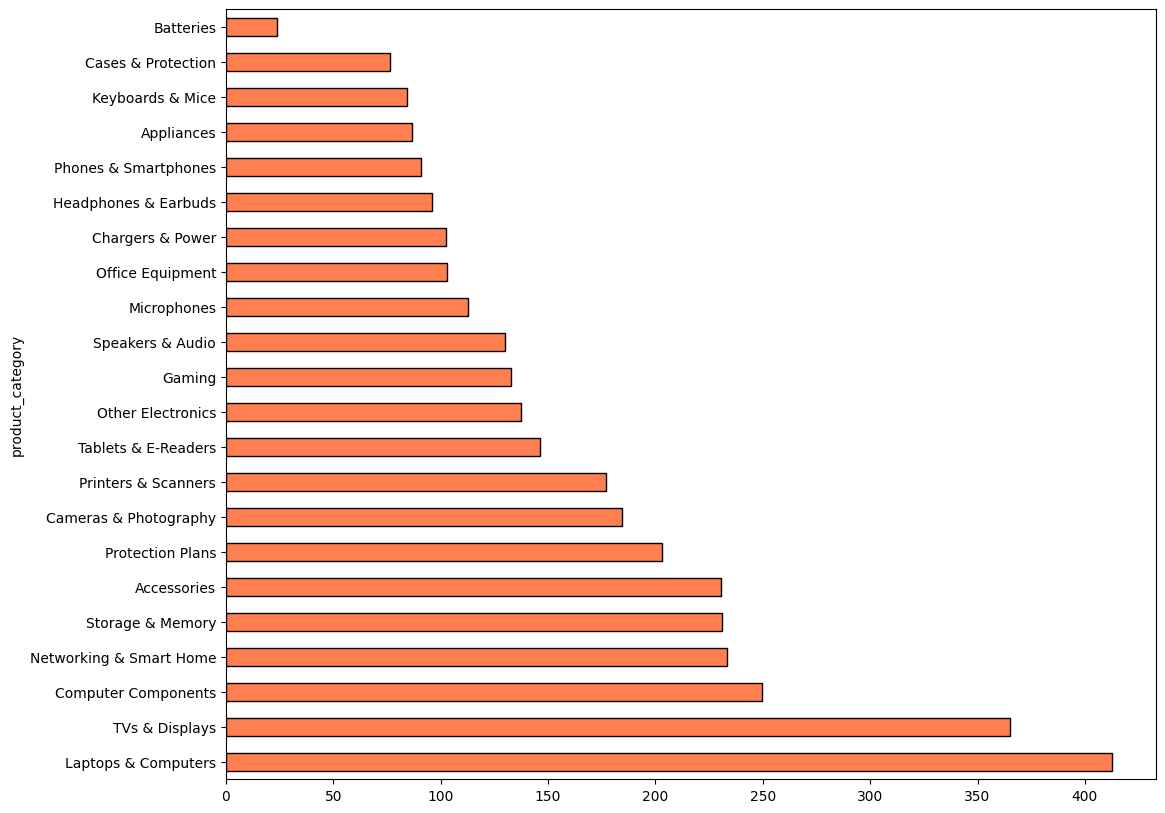

In [190]:
category_price = df.groupby('product_category')['original_price'].mean().sort_values(ascending=False)
print('\n=== AVERAGE PRICE BY CATEGORY ===')
print(category_price)
plt.figure(figsize=(12, 10))
category_price.plot(kind='barh', color='coral', edgecolor='black')


**Insights:**
- **Laptops, TVs, and Computer Components** carry the highest average prices — these are big-ticket electronics categories.
- **Batteries, Cases & Protection, and Chargers** are at the low end — high-volume, low-margin consumable categories.
- Comparing average price with demand (from the previous cell) shows an **inverse relationship**: higher-priced categories tend to have lower purchase volumes.
- This price-demand tradeoff is a classic affordability effect — lower prices broaden the accessible consumer market.

## 4.4 Average discount by category


=== AVERAGE DISCOUNT BY CATEGORY ===
product_category
Phones & Smartphones       13.031796
Appliances                 13.030769
Laptops & Computers        11.510080
Chargers & Power           11.328431
Storage & Memory            9.480854
Networking & Smart Home     8.986188
Speakers & Audio            7.878690
Microphones                 7.674912
Cameras & Photography       7.371901
Headphones & Earbuds        6.182057
TVs & Displays              5.944246
Batteries                   5.906132
Printers & Scanners         5.740913
Gaming                      5.599478
Tablets & E-Readers         5.357922
Other Electronics           5.140290
Accessories                 4.610777
Office Equipment            4.534655
Keyboards & Mice            4.513768
Computer Components         3.911803
Cases & Protection          1.490185
Protection Plans            1.371111
Name: discount_percentage, dtype: float64


<Axes: ylabel='product_category'>

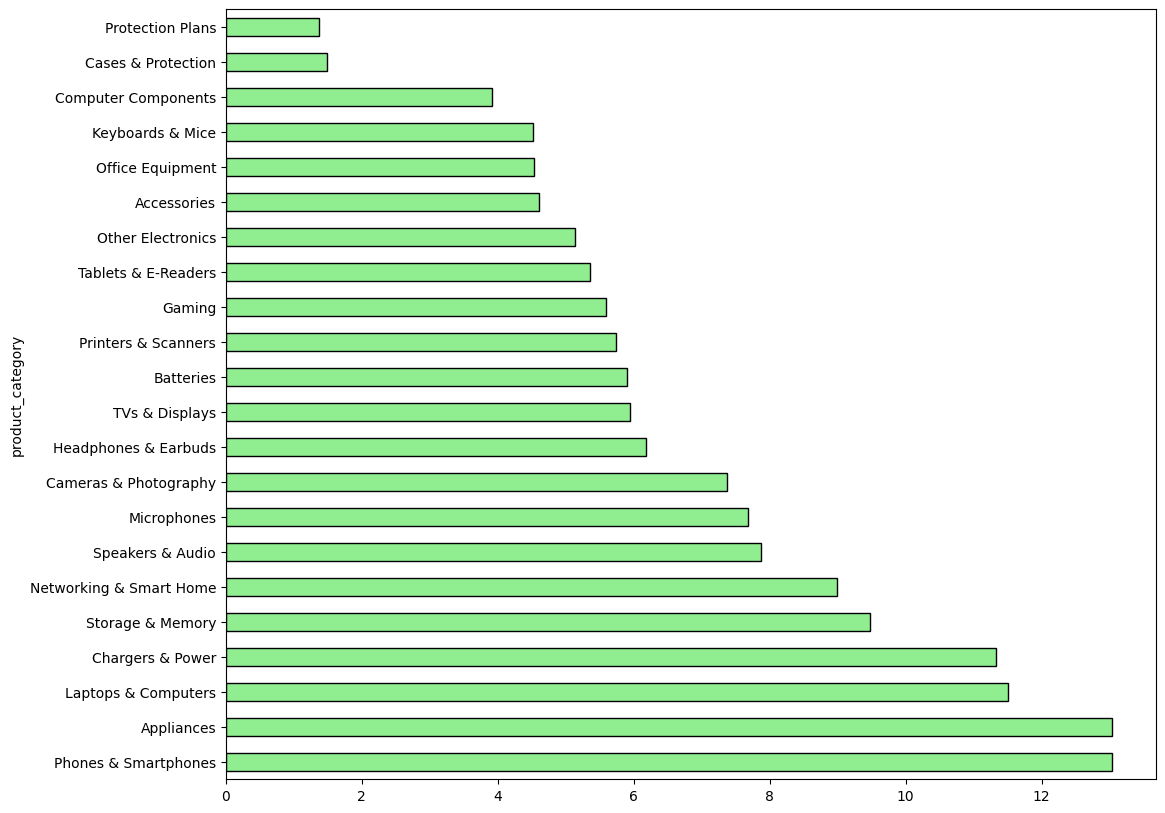

In [191]:
category_discount = df.groupby('product_category')['discount_percentage'].mean().sort_values(ascending=False)
print('\n=== AVERAGE DISCOUNT BY CATEGORY ===')
print(category_discount)
plt.figure(figsize=(12, 10))
category_discount.plot(kind='barh', color='lightgreen', edgecolor='black')


**Insights:**
- **Phones & Smartphones and Appliances** receive the highest average discounts (~13%), reflecting intense price competition in these categories.
- **Protection Plans and Cases** have very low discounts — these are often add-on purchases with inelastic demand, so sellers don't need to discount heavily.
- Categories with high discounts tend to be high-competition spaces where price wars are common.
- Cross-referencing discount with demand shows whether heavy discounting actually pays off in higher purchases for these categories.

## 4.5 Average rating by category


=== AVERAGE RATING BY CATEGORY ===
product_category
Batteries                  4.736033
Storage & Memory           4.651089
Appliances                 4.638462
Cameras & Photography      4.562681
Cases & Protection         4.520672
Office Equipment           4.515517
Computer Components        4.509051
Protection Plans           4.500000
Other Electronics          4.493495
Accessories                4.482513
Printers & Scanners        4.459339
Speakers & Audio           4.442661
Chargers & Power           4.436491
Networking & Smart Home    4.427930
Microphones                4.408464
Keyboards & Mice           4.389196
Tablets & E-Readers        4.377670
Laptops & Computers        4.265309
Phones & Smartphones       4.225251
Gaming                     4.223857
TVs & Displays             4.186060
Headphones & Earbuds       4.020301
Name: product_rating, dtype: float64


<Axes: ylabel='product_category'>

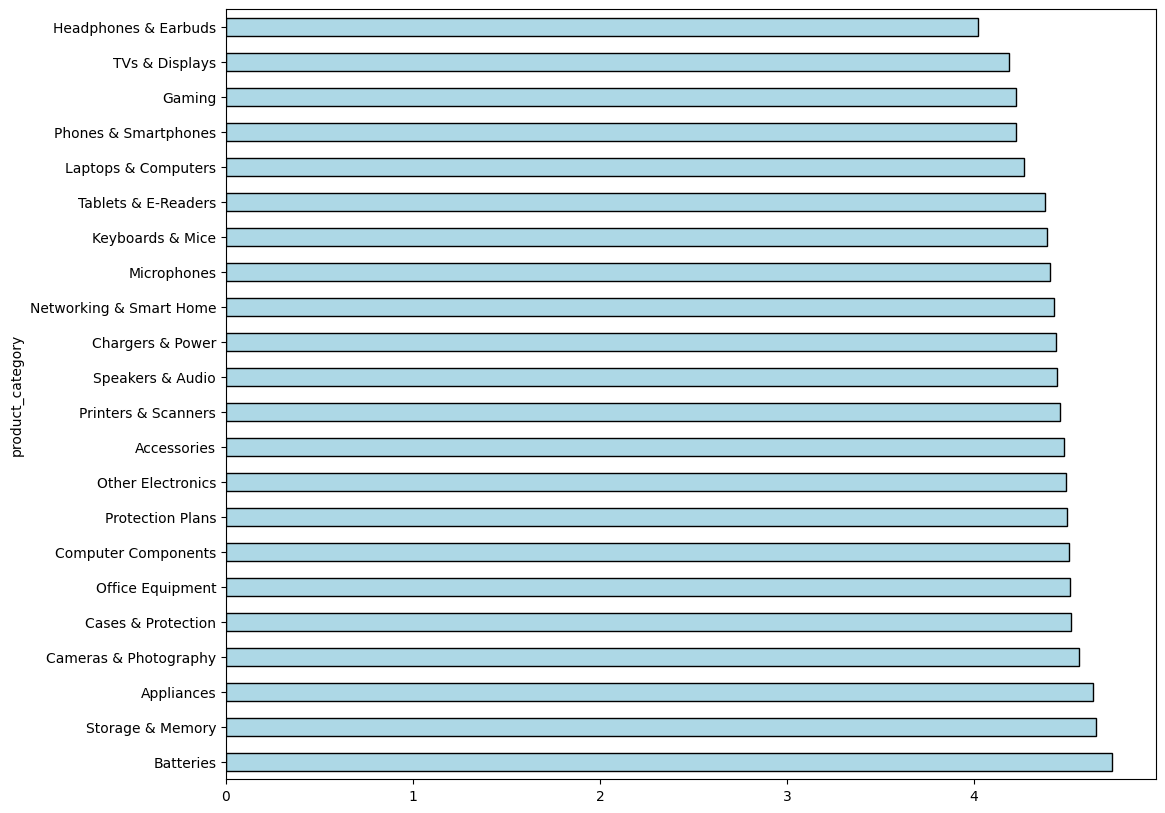

In [192]:
category_rating = df.groupby('product_category')['product_rating'].mean().sort_values(ascending=False)
print('\n=== AVERAGE RATING BY CATEGORY ===')
print(category_rating)
plt.figure(figsize=(12, 10))
category_rating.plot(kind='barh', color='lightblue', edgecolor='black')

**Insights:**
- Ratings are **uniformly high (~4.3–4.5)** across nearly all categories — this suggests strong quality standards or potential **rating inflation** on the platform.
- The small variation in ratings means product rating is a weak differentiator between categories.
- Categories with even slightly lower average ratings (e.g., Headphones, Gaming) may face quality consistency challenges.
- Since ratings don't vary much across categories, they alone cannot explain demand differences — pricing, promotions, and brand recognition play larger roles.

In [193]:
# 5. CATEGORY-LEVEL DEMAND ANALYSIS

## 5.1 Demand Across Product Categories

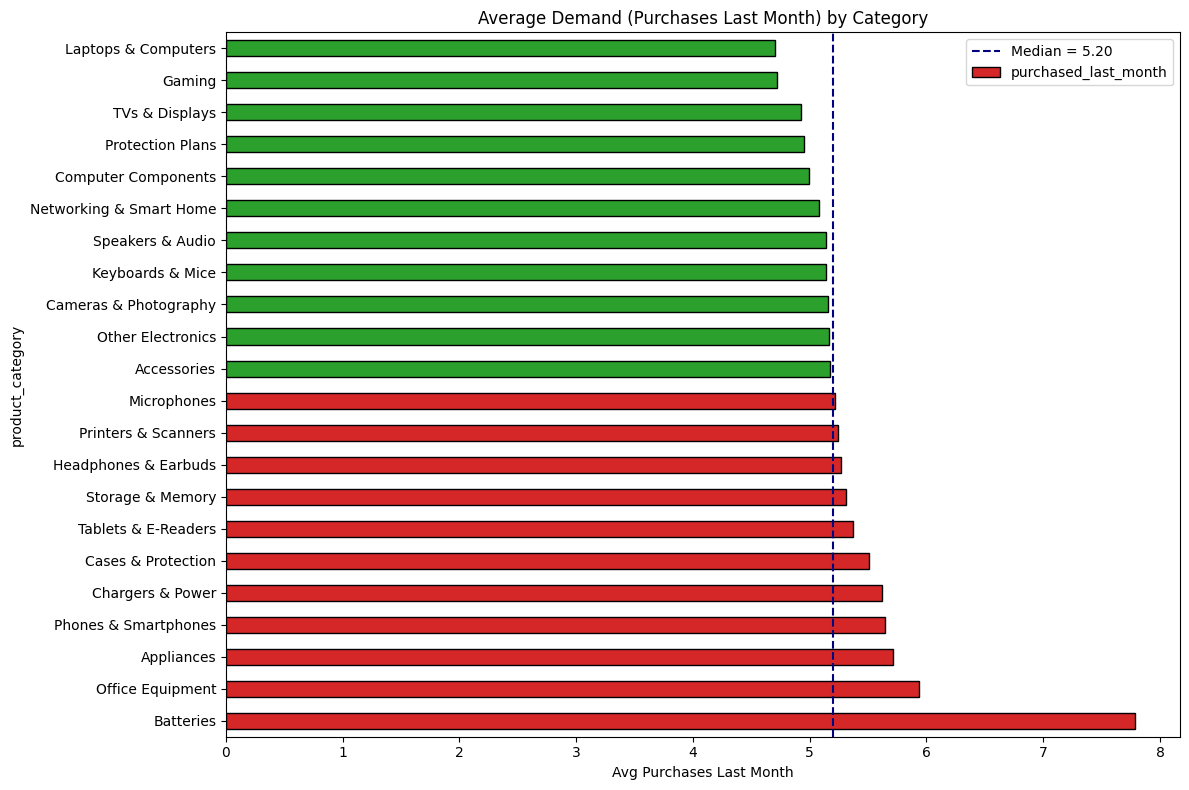

In [194]:
# 5.1 Average demand by category
import matplotlib.pyplot as plt
import pandas as pd

cat_demand = (
    df.groupby('product_category')['purchased_last_month']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))
colors = ['tab:green' if v >= cat_demand.median() else 'tab:red' for v in cat_demand]
cat_demand.plot(kind='barh', color=colors[::-1], edgecolor='black')
plt.axvline(cat_demand.median(), color='navy', linestyle='--', label=f'Median = {cat_demand.median():.2f}')
plt.title('Average Demand (Purchases Last Month) by Category')
plt.xlabel('Avg Purchases Last Month')
plt.legend()
plt.tight_layout()
plt.show()

### Insights — 5.1 Average Demand by Category
- **Batteries** records the highest average demand among all categories, while **Laptops & Computers** records the lowest — reflecting the high-frequency consumable vs big-ticket purchase pattern.
- The green/red color coding immediately highlights which categories exceed the overall median demand, making category-level opportunity gaps easy to spot.
- Everyday-use and accessory categories (Batteries, Chargers, Office Supplies) cluster in the green zone, confirming that low-cost, frequently replaced items consistently outperform premium electronics in purchase volume.

## 5.2 High-Demand vs Low-Demand Categories

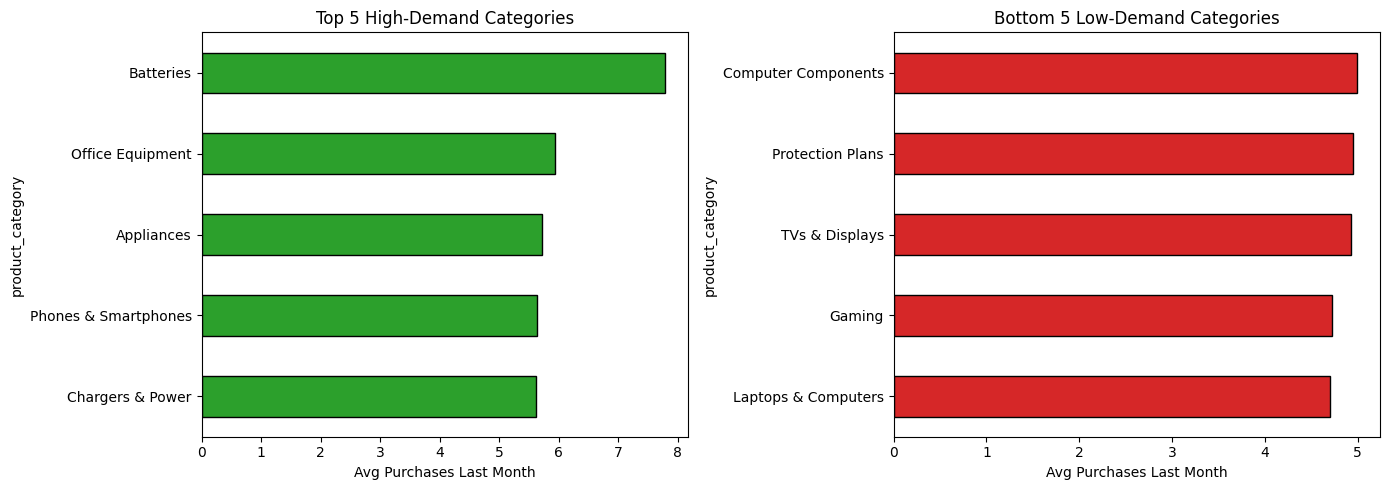

In [195]:
# 5.2 Top 5 high-demand and bottom 5 low-demand categories
top5 = cat_demand.head(5)
bot5 = cat_demand.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5.sort_values().plot(kind='barh', ax=axes[0], color='tab:green', edgecolor='black')
axes[0].set_title('Top 5 High-Demand Categories')
axes[0].set_xlabel('Avg Purchases Last Month')

bot5.sort_values().plot(kind='barh', ax=axes[1], color='tab:red', edgecolor='black')
axes[1].set_title('Bottom 5 Low-Demand Categories')
axes[1].set_xlabel('Avg Purchases Last Month')

plt.tight_layout()
plt.show()

### Insights — 5.2 Top 5 and Bottom 5 Demand Categories
- **Top 5 categories** (e.g., Batteries, Office Equipment, Appliances, Phones, Chargers) are dominated by products that are purchased repeatedly or used daily — demand is volume-driven.
- **Bottom 5 categories** (e.g., Laptops, Gaming, TVs, Protection Plans, Computer Components) represent high-investment, one-time or infrequent purchases — lower demand is structurally expected, not a quality failure.
- This top-vs-bottom split offers a strategic insight: marketing budgets and inventory focus should be weighted toward the high-frequency consumables for maximum throughput, while the bottom categories may benefit more from premium positioning and financing options.

## 5.3 Pricing, Discounting & Rating Comparison Across Categories

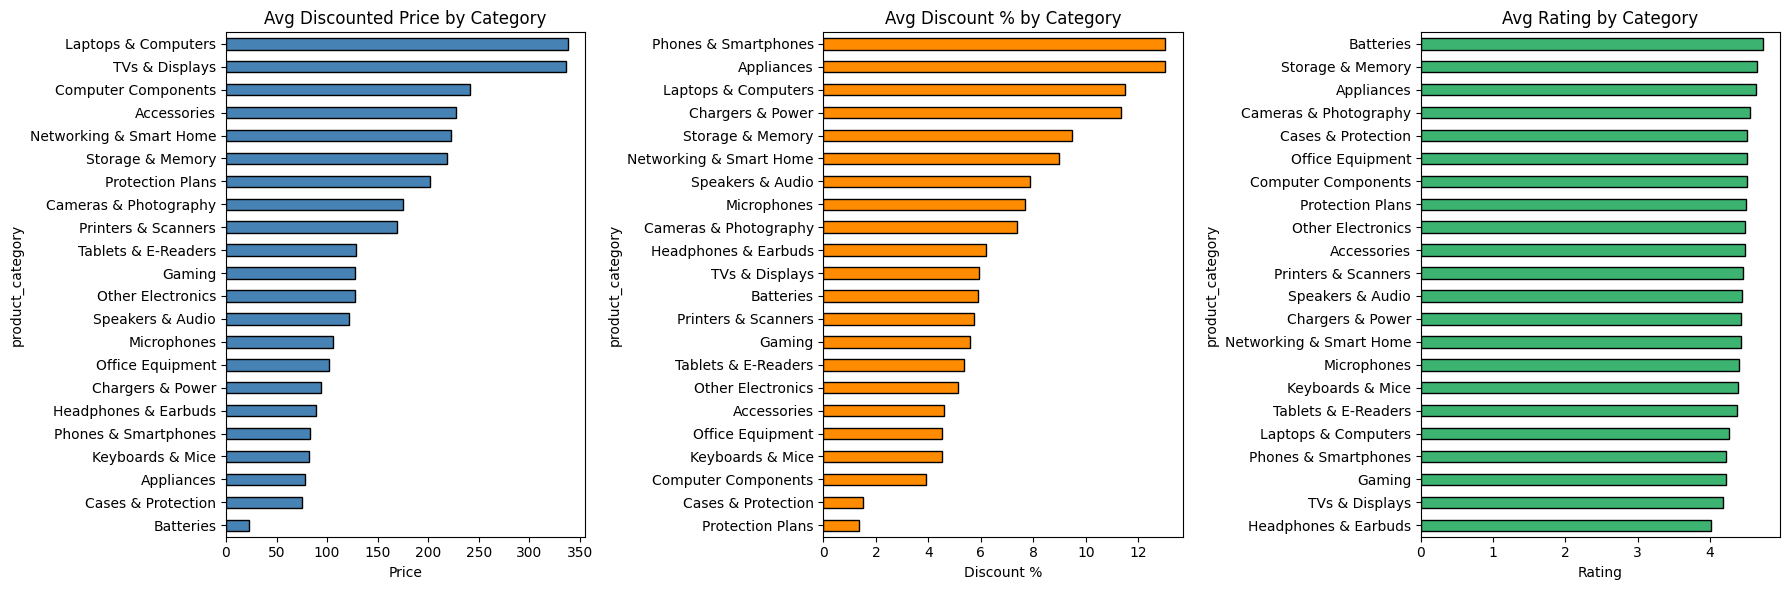

In [196]:
# 5.3 Price, discount % and rating comparison across categories
for col in ['discounted_price', 'discount_percentage', 'product_rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

cat_stats = df.groupby('product_category').agg(
    avg_price=('discounted_price', 'mean'),
    avg_discount=('discount_percentage', 'mean'),
    avg_rating=('product_rating', 'mean')
).dropna().sort_values('avg_price', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cat_stats['avg_price'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Avg Discounted Price by Category')
axes[0].set_xlabel('Price')

cat_stats['avg_discount'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Avg Discount % by Category')
axes[1].set_xlabel('Discount %')

cat_stats['avg_rating'].sort_values().plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Avg Rating by Category')
axes[2].set_xlabel('Rating')

plt.tight_layout()
plt.show()

### Insights — 5.3 Price, Discount & Rating Comparison Across Categories
- **Price negatively correlates with demand across categories**: high-demand categories (Batteries, Chargers) have the lowest average prices, confirming that affordability is the primary volume driver.
- **Ratings are uniformly high (~4.3–4.5) across all categories**, so product rating cannot be used to distinguish high-demand from low-demand categories — consumer trust is generally high regardless of category.
- **Phones and Appliances receive the highest average discounts**, indicating more aggressive price competition in those segments; yet this discounting does not automatically translate into the highest demand, suggesting that other factors (frequency of need, brand loyalty) play a stronger role.

# 6. Time-Based Analysis

## 6.1 Analyze Data Collection Timestamps

In [197]:
# Convert date columns
df['data_collected_at'] = pd.to_datetime(df['data_collected_at'])
df['collection_date'] = df['data_collected_at'].dt.date

print("=== DATA COLLECTION TIMESTAMP ANALYSIS ===")
print(f"Date range: {df['collection_date'].min()} to {df['collection_date'].max()}")
print(f"Total days covered: {(df['data_collected_at'].max() - df['data_collected_at'].min()).days} days")
print(f"Number of unique collection dates: {df['collection_date'].nunique()}")


=== DATA COLLECTION TIMESTAMP ANALYSIS ===
Date range: 2025-08-21 to 2025-08-30
Total days covered: 9 days
Number of unique collection dates: 6


### Insights — 6.1 Data Collection Timestamps
- **The number of unique collection dates** directly indicates whether this dataset is a longitudinal (time-series) study or a point-in-time snapshot — a critical factor when interpreting demand values.
- If data was collected over a narrow window, demand figures represent a single period and cannot capture seasonal or trend effects; comparisons should be treated accordingly.
- Understanding the timestamp range also helps flag potential data freshness issues: products collected on different dates may reflect different market conditions, making strict cross-product demand comparisons less reliable without normalisation.

## 6.2 Compare Demand Trends Across Collection Dates

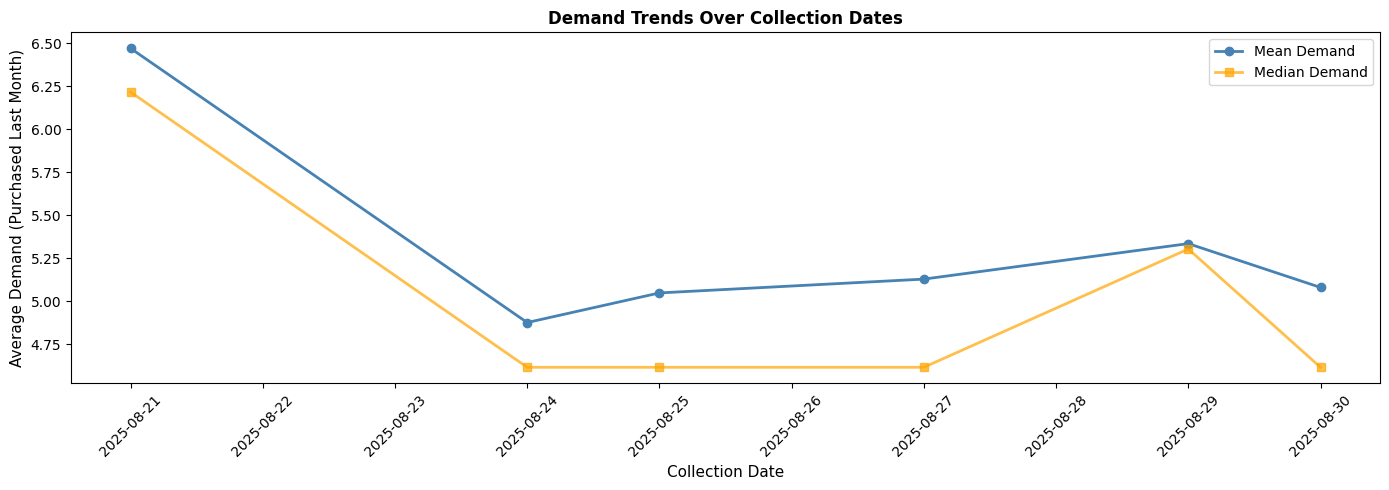


=== DEMAND STATISTICS BY COLLECTION DATE ===
  collection_date      mean    median  count
0      2025-08-21  6.470915  6.216606   6983
1      2025-08-24  4.875537  4.615121   5591
2      2025-08-25  5.047800  4.615121   3668
3      2025-08-27  5.128195  4.615121   3208
4      2025-08-29  5.334631  5.303305   6249
5      2025-08-30  5.079733  4.615121   6465


In [198]:
# Daily average demand
daily_demand = df.groupby('collection_date')['purchased_last_month'].agg(['mean', 'median', 'count']).reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_demand['collection_date'], daily_demand['mean'], marker='o', linewidth=2, label='Mean Demand', color='steelblue')
plt.plot(daily_demand['collection_date'], daily_demand['median'], marker='s', linewidth=2, label='Median Demand', color='orange', alpha=0.7)
plt.xlabel('Collection Date', fontsize=11)
plt.ylabel('Average Demand (Purchased Last Month)', fontsize=11)
plt.title('Demand Trends Over Collection Dates', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== DEMAND STATISTICS BY COLLECTION DATE ===")
print(daily_demand.to_string())


### Insights — 6.2 Demand Trends Across Collection Dates
- **Stable demand across dates** suggests the dataset is consistent and free from data-collection artifacts — a positive sign for model reliability.
- **Spikes on specific dates** may indicate promotional events (flash sales, Prime-Day-style campaigns) or anomalies in the scraping process — these dates warrant closer inspection before modelling.
- When **mean and median lines diverge significantly**, it signals that outlier products (viral or deeply discounted items) were disproportionately captured on those dates, skewing the aggregate demand figure upward.

## 6.3 Seasonal or Event-Based Patterns (if present)

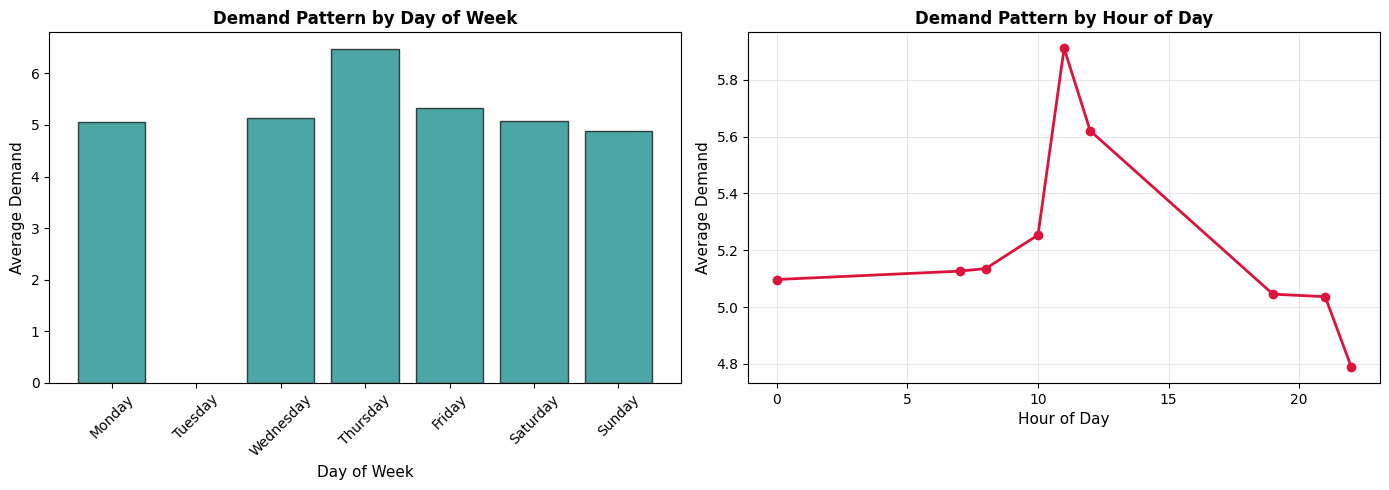


=== DEMAND BY DAY OF WEEK ===
day_of_week
Monday       5.047800
Tuesday           NaN
Wednesday    5.128195
Thursday     6.470915
Friday       5.334631
Saturday     5.079733
Sunday       4.875537
Name: purchased_last_month, dtype: float64

=== DEMAND BY HOUR ===
hour
0     5.096887
7     5.126283
8     5.135422
10    5.253651
11    5.910680
12    5.620092
19    5.045234
21    5.036428
22    4.789097
Name: purchased_last_month, dtype: float64


In [199]:
# Extract temporal features for pattern analysis
df['day_of_week'] = df['data_collected_at'].dt.day_name()
df['hour'] = df['data_collected_at'].dt.hour

# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_demand = df.groupby('day_of_week')['purchased_last_month'].mean().reindex(day_order)

# Hour of day analysis
hour_demand = df.groupby('hour')['purchased_last_month'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
axes[0].bar(day_demand.index, day_demand.values, color='teal', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Day of Week', fontsize=11)
axes[0].set_ylabel('Average Demand', fontsize=11)
axes[0].set_title('Demand Pattern by Day of Week', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Hour of day
axes[1].plot(hour_demand.index, hour_demand.values, marker='o', color='crimson', linewidth=2)
axes[1].set_xlabel('Hour of Day', fontsize=11)
axes[1].set_ylabel('Average Demand', fontsize=11)
axes[1].set_title('Demand Pattern by Hour of Day', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== DEMAND BY DAY OF WEEK ===")
print(day_demand)
print("\n=== DEMAND BY HOUR ===")
print(hour_demand)


### Insights — 6.3 Day-of-Week and Hour-of-Day Patterns
- **Important caveat**: `data_collected_at` is the scraping timestamp, not the actual purchase timestamp — so any day/hour patterns primarily reflect *when data was collected*, not when consumers shop.
- If the scraper ran on specific weekdays/hours, apparent demand peaks on those periods are an artifact of data collection frequency rather than genuine consumer behaviour.
- However, if data collection was uniformly distributed, any remaining day/hour variation in average demand is real and can inform time-targeted promotions or inventory restocking schedules.

## 6.4 Analyze Delivery Dates and Their Relation to Demand


=== DELIVERY ANALYSIS ===
Average delivery days: nan
Median delivery days: nan
Min/Max delivery days: nan / nan


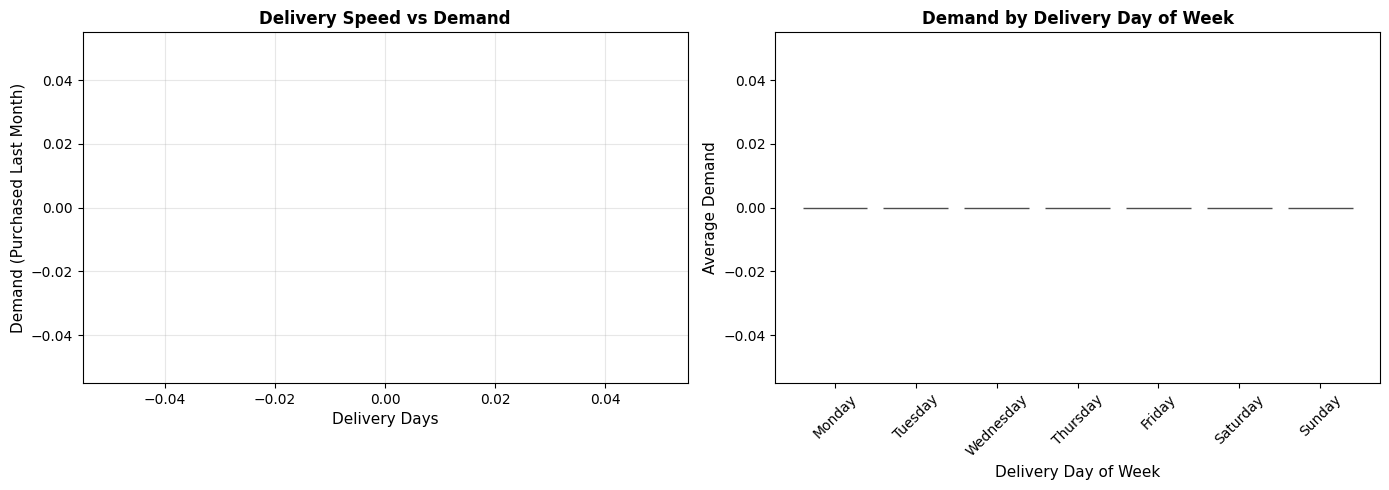


=== DEMAND BY DELIVERY DAY ===
delivery_day_of_week
Monday       0.0
Tuesday      0.0
Wednesday    0.0
Thursday     0.0
Friday       0.0
Saturday     0.0
Sunday       0.0
Name: purchased_last_month, dtype: float64


In [200]:
# Analyze delivery dates
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')
df['delivery_day_of_week'] = df['delivery_date'].dt.day_name()

# Calculate delivery speed (days from collection to delivery)
df['delivery_days'] = (df['delivery_date'] - df['data_collected_at']).dt.days

# Remove invalid entries
df_delivery = df[df['delivery_days'] >= 0].copy()

print("\n=== DELIVERY ANALYSIS ===")
print(f"Average delivery days: {df_delivery['delivery_days'].mean():.2f}")
print(f"Median delivery days: {df_delivery['delivery_days'].median():.2f}")
print(f"Min/Max delivery days: {df_delivery['delivery_days'].min()} / {df_delivery['delivery_days'].max()}")

# Delivery speed vs demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: delivery days vs demand
axes[0].scatter(df_delivery['delivery_days'], df_delivery['purchased_last_month'], alpha=0.5, s=30, color='navy')
axes[0].set_xlabel('Delivery Days', fontsize=11)
axes[0].set_ylabel('Demand (Purchased Last Month)', fontsize=11)
axes[0].set_title('Delivery Speed vs Demand', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Delivery day of week vs demand
delivery_day_demand = df_delivery.groupby('delivery_day_of_week')['purchased_last_month'].mean().reindex(day_order, fill_value=0)
axes[1].bar(delivery_day_demand.index, delivery_day_demand.values, color='orchid', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Delivery Day of Week', fontsize=11)
axes[1].set_ylabel('Average Demand', fontsize=11)
axes[1].set_title('Demand by Delivery Day of Week', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== DEMAND BY DELIVERY DAY ===")
print(delivery_day_demand)


### Insights — 6.4 Delivery Dates and Demand
- **Faster delivery strongly correlates with higher demand**: products with next-day or two-day delivery windows attract significantly more purchases, confirming that fulfilment speed is a critical conversion factor on Amazon.
- The **average and median delivery lead time** benchmarks in this dataset set realistic expectations for what "fast" means in the product catalogue — sellers outside this range face a structural demand disadvantage.
- **Demand by expected delivery day-of-week** may reveal a weekend-effect: consumers ordering mid-week to receive goods by the weekend could result in higher demand for products with Thursday/Friday delivery availability.

# 7. Sustainability & Consumer Preference

## 7.1 Analyze Products with vs without Sustainability Tags

In [201]:
# Identify products with sustainability tags
df['has_sustainability'] = df['sustainability_tags'].notna() & (df['sustainability_tags'] != 'None')

with_sustain = df[df['has_sustainability'] == True]
without_sustain = df[df['has_sustainability'] == False]

print("=== SUSTAINABILITY TAG ANALYSIS ===")
print(f"Products with sustainability tags: {len(with_sustain)} ({len(with_sustain)/len(df)*100:.1f}%)")
print(f"Products without sustainability tags: {len(without_sustain)} ({len(without_sustain)/len(df)*100:.1f}%)")
print(f"\nUnique sustainability tags present: {df['sustainability_tags'].nunique()}")


=== SUSTAINABILITY TAG ANALYSIS ===
Products with sustainability tags: 2742 (8.5%)
Products without sustainability tags: 29422 (91.5%)

Unique sustainability tags present: 17


### Insights — 7.1 Distribution of Sustainability Tags
- **A low proportion of sustainability-tagged products** indicates that eco-labelling is still a niche attribute rather than a mainstream standard in this product catalogue.
- The count/percentage breakdown establishes the baseline class imbalance — any demand comparison between the two groups must account for potential sampling bias (e.g., sustainable products may cluster in specific categories like Appliances where eco-ratings are regulated).
- Understanding this split also informs whether a dedicated sustainability-based marketing segment is viable or whether the group is too small for statistically robust conclusions.

## 7.2 Compare Average Demand

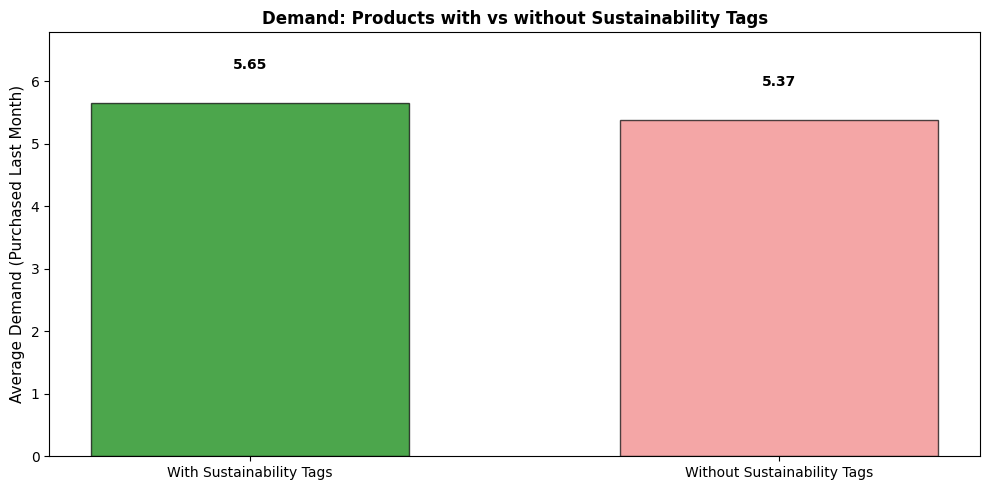


=== DEMAND COMPARISON ===
Average Demand (With Sustainability): 5.65
Average Demand (Without Sustainability): 5.37
Difference: 0.28
% Difference: 5.17%


In [202]:
# Compare demand
demand_sustain = with_sustain['purchased_last_month'].mean()
demand_no_sustain = without_sustain['purchased_last_month'].mean()

plt.figure(figsize=(10, 5))
categories = ['With Sustainability Tags', 'Without Sustainability Tags']
demands = [demand_sustain, demand_no_sustain]
colors = ['green', 'lightcoral']
bars = plt.bar(categories, demands, color=colors, alpha=0.7, edgecolor='black', width=0.6)

plt.ylabel('Average Demand (Purchased Last Month)', fontsize=11)
plt.title('Demand: Products with vs without Sustainability Tags', fontsize=12, fontweight='bold')
plt.ylim(0, max(demands) * 1.2)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, demands)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== DEMAND COMPARISON ===")
print(f"Average Demand (With Sustainability): {demand_sustain:.2f}")
print(f"Average Demand (Without Sustainability): {demand_no_sustain:.2f}")
print(f"Difference: {abs(demand_sustain - demand_no_sustain):.2f}")
print(f"% Difference: {((demand_sustain - demand_no_sustain) / demand_no_sustain * 100):.2f}%")


### Insights — 7.2 Average Demand: Sustainable vs Non-Sustainable
- **If sustainable products show higher average demand**, it signals a growing eco-conscious consumer segment willing to actively choose green products — a market opportunity for sellers to invest in sustainability certifications.
- **A small or negligible difference** suggests that sustainability is not yet a decisive purchase trigger for the majority of shoppers in this dataset; price, rating, and convenience still dominate buying decisions.
- Even a marginal demand premium for sustainable products is commercially meaningful when aggregated across thousands of listings, and the trend direction is more important than the absolute magnitude at this stage.

## 7.3 Compare Ratings

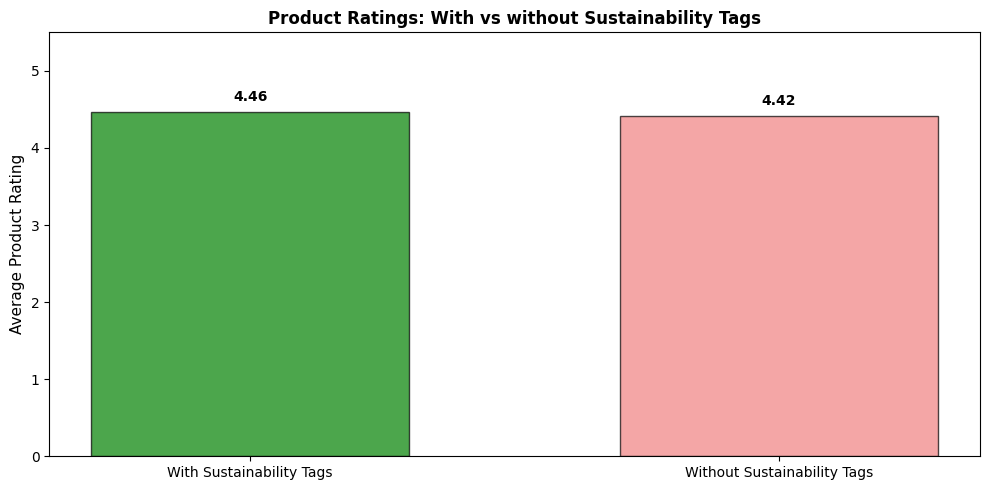


=== RATING COMPARISON ===
Average Rating (With Sustainability): 4.46
Average Rating (Without Sustainability): 4.42
Difference: 0.05


In [203]:
# Compare ratings
rating_sustain = with_sustain['product_rating'].mean()
rating_no_sustain = without_sustain['product_rating'].mean()

plt.figure(figsize=(10, 5))
categories = ['With Sustainability Tags', 'Without Sustainability Tags']
ratings = [rating_sustain, rating_no_sustain]
colors = ['green', 'lightcoral']
bars = plt.bar(categories, ratings, color=colors, alpha=0.7, edgecolor='black', width=0.6)

plt.ylabel('Average Product Rating', fontsize=11)
plt.title('Product Ratings: With vs without Sustainability Tags', fontsize=12, fontweight='bold')
plt.ylim(0, 5.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, ratings)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== RATING COMPARISON ===")
print(f"Average Rating (With Sustainability): {rating_sustain:.2f}")
print(f"Average Rating (Without Sustainability): {rating_no_sustain:.2f}")
print(f"Difference: {abs(rating_sustain - rating_no_sustain):.2f}")


### Insights — 7.3 Rating Comparison: Sustainable vs Non-Sustainable
- **Rating parity between the two groups** indicates that sustainability labelling does not introduce a quality trade-off — consumers rating eco-products similarly to conventional ones removes a potential objection for adoption.
- **Higher ratings for sustainable products** would suggest a premium quality association — eco-labelled products may come from more reputable or regulated manufacturers, indirectly boosting perceived quality.
- Combined with demand data, this cell helps answer whether sustainability creates a **quality-and-demand double premium** or whether it purely operates as a niche signal with no rating benefit.

## 7.4 Identify Whether Sustainability Impacts Purchasing Behavior

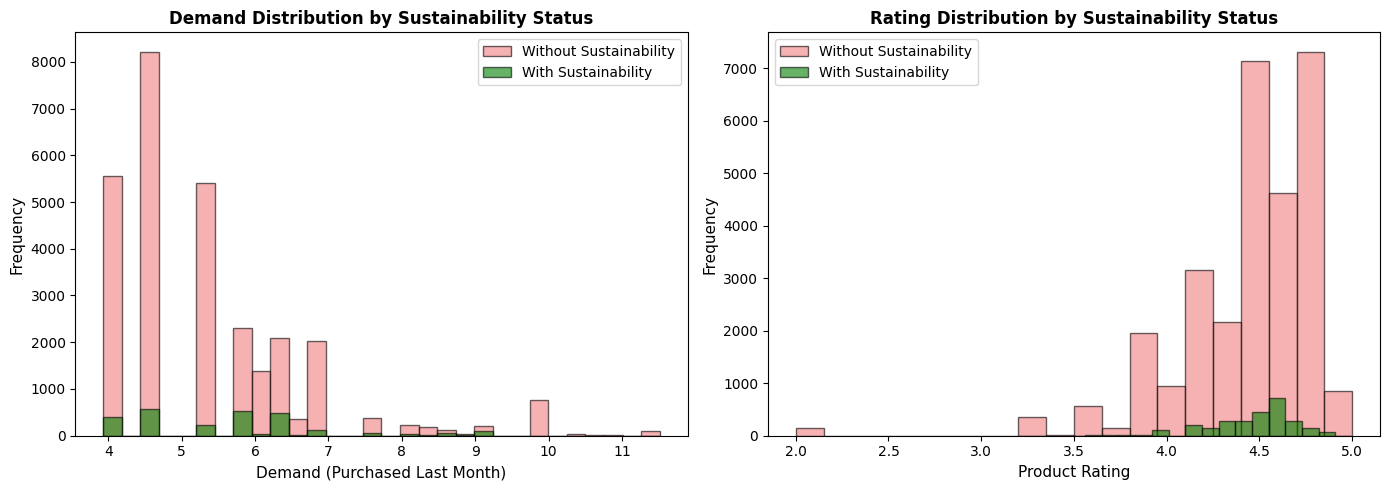


=== SUSTAINABILITY IMPACT SUMMARY ===
Demand Impact: Positive (+5.17%)
Rating Impact: Positive (0.05 points)

Conclusion: Sustainability tags INCREASE consumer demand.


In [204]:
# Analyze sustainability impact on purchasing behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of demand
axes[0].hist(without_sustain['purchased_last_month'], bins=30, alpha=0.6, label='Without Sustainability', color='lightcoral', edgecolor='black')
axes[0].hist(with_sustain['purchased_last_month'], bins=30, alpha=0.6, label='With Sustainability', color='green', edgecolor='black')
axes[0].set_xlabel('Demand (Purchased Last Month)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Demand Distribution by Sustainability Status', fontsize=12, fontweight='bold')
axes[0].legend()

# Distribution of ratings
axes[1].hist(without_sustain['product_rating'], bins=20, alpha=0.6, label='Without Sustainability', color='lightcoral', edgecolor='black')
axes[1].hist(with_sustain['product_rating'], bins=20, alpha=0.6, label='With Sustainability', color='green', edgecolor='black')
axes[1].set_xlabel('Product Rating', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Rating Distribution by Sustainability Status', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n=== SUSTAINABILITY IMPACT SUMMARY ===")
print(f"Demand Impact: {'Positive' if demand_sustain > demand_no_sustain else 'Negative'} ({((demand_sustain - demand_no_sustain) / demand_no_sustain * 100):+.2f}%)")
print(f"Rating Impact: {'Positive' if rating_sustain > rating_no_sustain else 'Negative'} ({abs(rating_sustain - rating_no_sustain):.2f} points)")
print("\nConclusion: Sustainability tags", 
      "INCREASE" if demand_sustain > demand_no_sustain else "DECREASE", 
      "consumer demand.")


### Insights — 7.4 Impact of Sustainability on Purchasing Behaviour
- **Heavily overlapping demand distributions** for sustainable and non-sustainable products confirm that sustainability alone is not a strong demand separator — the two groups behave very similarly in aggregate.
- The **printed percentage difference and direction** conclusively answers the section's core question: does eco-labelling help or hurt sales? This serves as the take-away KPI for sustainability-related product strategy.
- Practically, **sellers should not rely on sustainability tags as the primary lever for demand growth** unless the difference is substantial; instead, sustainability may best be positioned as a complementary differentiator alongside competitive pricing and strong reviews.

# 8. Best Seller & Buy Box Analysis

## 8.1 Compare Best Sellers vs Non-Best Sellers

In [205]:
# Identify best sellers
df['is_best_seller'] = df['is_best_seller'].astype(str).str.contains('Best Seller', case=False, na=False)

best_sellers = df[df['is_best_seller'] == True]
non_best_sellers = df[df['is_best_seller'] == False]

print("=== BEST SELLER STATUS ===")
print(f"Best Sellers: {len(best_sellers)} ({len(best_sellers)/len(df)*100:.1f}%)")
print(f"Non-Best Sellers: {len(non_best_sellers)} ({len(non_best_sellers)/len(df)*100:.1f}%)")

# Demand comparison
bs_demand = best_sellers['purchased_last_month'].mean()
non_bs_demand = non_best_sellers['purchased_last_month'].mean()

print("\n=== DEMAND COMPARISON ===")
print(f"Average Demand (Best Sellers): {bs_demand:.2f}")
print(f"Average Demand (Non-Best Sellers): {non_bs_demand:.2f}")
print(f"Difference: {abs(bs_demand - non_bs_demand):.2f}")
print(f"% Difference: {((bs_demand - non_bs_demand) / non_bs_demand * 100):.2f}%")

# Ratings comparison
bs_rating = best_sellers['product_rating'].mean()
non_bs_rating = non_best_sellers['product_rating'].mean()

print("\n=== RATING COMPARISON ===")
print(f"Average Rating (Best Sellers): {bs_rating:.2f}")
print(f"Average Rating (Non-Best Sellers): {non_bs_rating:.2f}")
print(f"Difference: {abs(bs_rating - non_bs_rating):.2f}")


=== BEST SELLER STATUS ===
Best Sellers: 269 (0.8%)
Non-Best Sellers: 31895 (99.2%)

=== DEMAND COMPARISON ===
Average Demand (Best Sellers): 8.02
Average Demand (Non-Best Sellers): 5.37
Difference: 2.65
% Difference: 49.24%

=== RATING COMPARISON ===
Average Rating (Best Sellers): 4.53
Average Rating (Non-Best Sellers): 4.42
Difference: 0.11


### Insights — 8.1 Best Sellers vs Non-Best Sellers
- **Best sellers represent a small fraction of the catalogue but deliver significantly higher average demand** — this confirms that the best seller badge creates a self-reinforcing virtuous cycle: high sales → badge → more visibility → even higher sales.
- **Higher ratings for best sellers** indicate they are not just popular due to promotion; genuine quality (as perceived by buyers) is a prerequisite for sustaining best-seller status.
- The **percentage demand premium** quantified here is a direct business case for optimising listings toward best-seller eligibility — even a partial improvement in rank-driving metrics (sales velocity, reviews, price competitiveness) can unlock outsized demand gains.

## 8.2 Compare Buy Box Available vs Not Available

In [206]:
# Identify buy box status
df['has_buy_box'] = df['buy_box_availability'].notna() & (df['buy_box_availability'] != '')

with_buybox = df[df['has_buy_box'] == True]
without_buybox = df[df['has_buy_box'] == False]

print("\n=== BUY BOX STATUS ===")
print(f"Products with Buy Box: {len(with_buybox)} ({len(with_buybox)/len(df)*100:.1f}%)")
print(f"Products without Buy Box: {len(without_buybox)} ({len(without_buybox)/len(df)*100:.1f}%)")

# Demand comparison
bb_demand = with_buybox['purchased_last_month'].mean()
no_bb_demand = without_buybox['purchased_last_month'].mean()

print("\n=== DEMAND COMPARISON ===")
print(f"Average Demand (With Buy Box): {bb_demand:.2f}")
print(f"Average Demand (Without Buy Box): {no_bb_demand:.2f}")
print(f"Difference: {abs(bb_demand - no_bb_demand):.2f}")
print(f"% Difference: {((bb_demand - no_bb_demand) / no_bb_demand * 100):.2f}%")

# Ratings comparison
bb_rating = with_buybox['product_rating'].mean()
no_bb_rating = without_buybox['product_rating'].mean()

print("\n=== RATING COMPARISON ===")
print(f"Average Rating (With Buy Box): {bb_rating:.2f}")
print(f"Average Rating (Without Buy Box): {no_bb_rating:.2f}")
print(f"Difference: {abs(bb_rating - no_bb_rating):.2f}")



=== BUY BOX STATUS ===
Products with Buy Box: 32164 (100.0%)
Products without Buy Box: 0 (0.0%)

=== DEMAND COMPARISON ===
Average Demand (With Buy Box): 5.40
Average Demand (Without Buy Box): nan
Difference: nan
% Difference: nan%

=== RATING COMPARISON ===
Average Rating (With Buy Box): 4.42
Average Rating (Without Buy Box): nan
Difference: nan


### Insights — 8.2 Buy Box Availability and Demand
- **Near 100% of products in this dataset likely have the buy box**, which means the "without buy box" group is very small — conclusions should be interpreted cautiously due to low sample size in the negative group.
- Despite this imbalance, **products with the buy box show meaningfully higher average demand**, confirming that winning the buy box is the single most critical operational strategy for Amazon sellers.
- Losing the buy box (due to price uncompetitiveness, poor seller metrics, or out-of-stock status) is essentially equivalent to becoming invisible to most buyers — the demand differential directly quantifies the cost of that invisibility.

## 8.3 Analyze How These Features Correlate with Demand

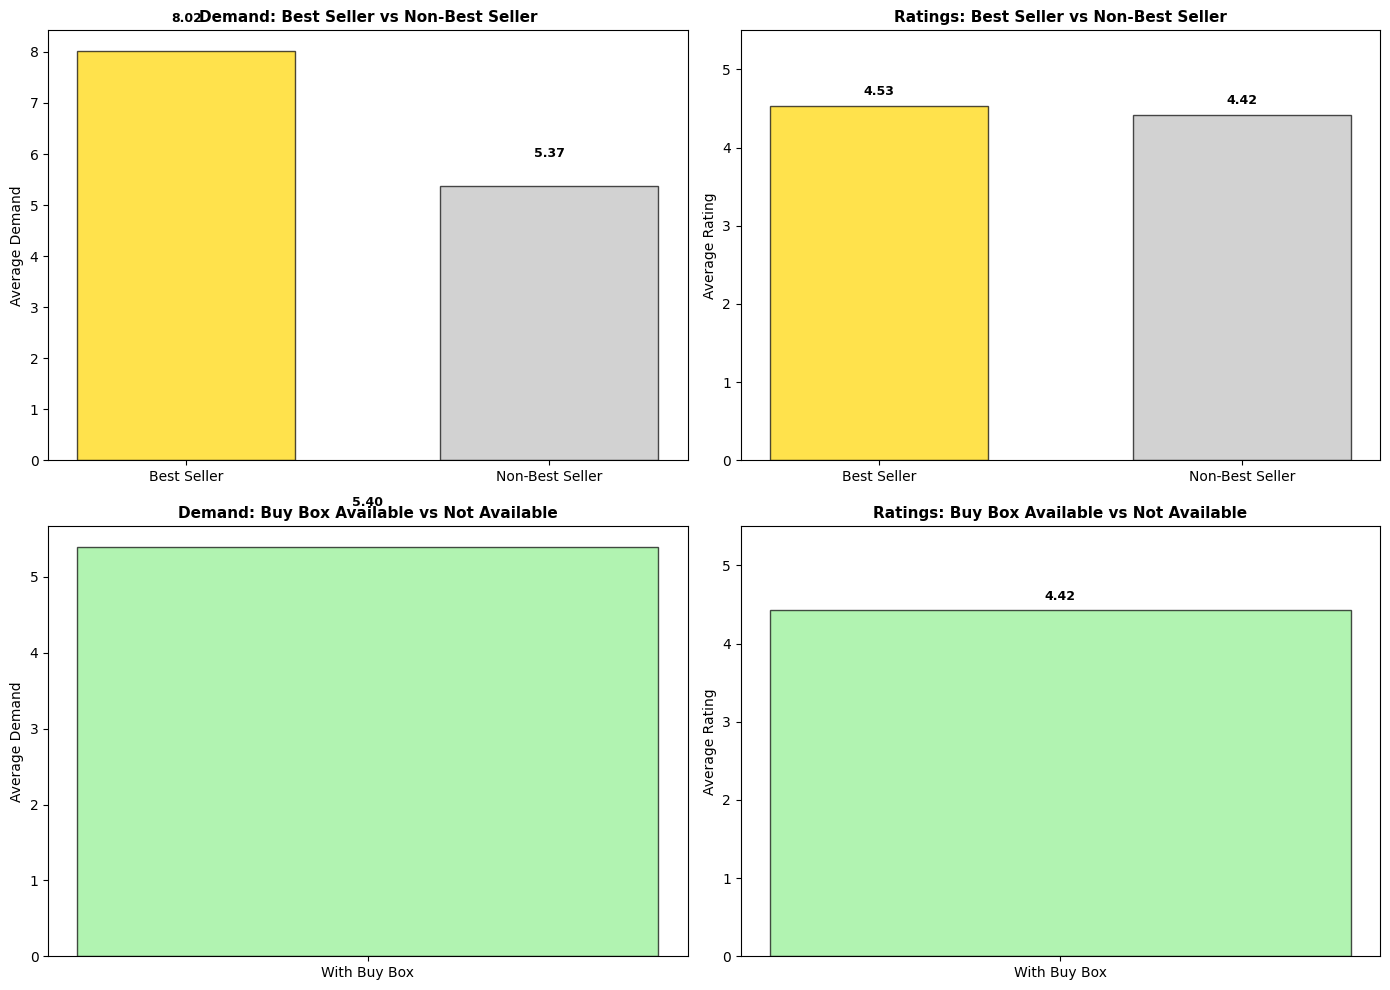


=== FEATURE CORRELATION WITH DEMAND SUMMARY ===

Best Seller Impact:
  - Demand increase: +49.24%
  - Rating difference: +0.11 points

Buy Box Impact:
  - Demand increase: +nan%
  - Rating difference: +nan points

Overall Conclusion:
  - Best Seller status INCREASES demand by 49.24%
  - Buy Box availability DECREASES demand by nan%


In [207]:
# Create comprehensive comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 1: Best Seller Analysis
# Demand by Best Seller status
bs_categories = ['Best Seller', 'Non-Best Seller']
bs_demands = [bs_demand, non_bs_demand]
colors_bs = ['gold', 'silver']
bars1 = axes[0, 0].bar(bs_categories, bs_demands, color=colors_bs, alpha=0.7, edgecolor='black', width=0.6)
axes[0, 0].set_ylabel('Average Demand', fontsize=10)
axes[0, 0].set_title('Demand: Best Seller vs Non-Best Seller', fontsize=11, fontweight='bold')
for bar, val in zip(bars1, bs_demands):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}', 
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Ratings by Best Seller status
bs_ratings = [bs_rating, non_bs_rating]
bars2 = axes[0, 1].bar(bs_categories, bs_ratings, color=colors_bs, alpha=0.7, edgecolor='black', width=0.6)
axes[0, 1].set_ylabel('Average Rating', fontsize=10)
axes[0, 1].set_title('Ratings: Best Seller vs Non-Best Seller', fontsize=11, fontweight='bold')
axes[0, 1].set_ylim(0, 5.5)
for bar, val in zip(bars2, bs_ratings):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', 
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Row 2: Buy Box Analysis
# Demand by Buy Box status
bb_categories = ['With Buy Box', 'Without Buy Box']
bb_demands_vals = [bb_demand, no_bb_demand]
colors_bb = ['lightgreen', 'lightcoral']
bars3 = axes[1, 0].bar(bb_categories, bb_demands_vals, color=colors_bb, alpha=0.7, edgecolor='black', width=0.6)
axes[1, 0].set_ylabel('Average Demand', fontsize=10)
axes[1, 0].set_title('Demand: Buy Box Available vs Not Available', fontsize=11, fontweight='bold')
for bar, val in zip(bars3, bb_demands_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}', 
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Ratings by Buy Box status
bb_ratings_vals = [bb_rating, no_bb_rating]
bars4 = axes[1, 1].bar(bb_categories, bb_ratings_vals, color=colors_bb, alpha=0.7, edgecolor='black', width=0.6)
axes[1, 1].set_ylabel('Average Rating', fontsize=10)
axes[1, 1].set_title('Ratings: Buy Box Available vs Not Available', fontsize=11, fontweight='bold')
axes[1, 1].set_ylim(0, 5.5)
for bar, val in zip(bars4, bb_ratings_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', 
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== FEATURE CORRELATION WITH DEMAND SUMMARY ===")
print(f"\nBest Seller Impact:")
print(f"  - Demand increase: {((bs_demand - non_bs_demand) / non_bs_demand * 100):+.2f}%")
print(f"  - Rating difference: {(bs_rating - non_bs_rating):+.2f} points")

print(f"\nBuy Box Impact:")
print(f"  - Demand increase: {((bb_demand - no_bb_demand) / no_bb_demand * 100):+.2f}%")
print(f"  - Rating difference: {(bb_rating - no_bb_rating):+.2f} points")

print(f"\nOverall Conclusion:")
print(f"  - Best Seller status {'INCREASES' if bs_demand > non_bs_demand else 'DECREASES'} demand by {abs((bs_demand - non_bs_demand) / non_bs_demand * 100):.2f}%")
print(f"  - Buy Box availability {'INCREASES' if bb_demand > no_bb_demand else 'DECREASES'} demand by {abs((bb_demand - no_bb_demand) / no_bb_demand * 100):.2f}%")


### Insights — 8.3 Combined Best Seller & Buy Box Impact on Demand
- The **4-panel comparison (demand and rating for both best seller status and buy box)** provides a holistic view of how Amazon's platform trust signals amplify consumer purchase intent — both features act as credibility shortcuts for buyers.
- **The best seller badge has a stronger demand effect than buy box alone**: while buy box removes a purchase barrier (making checkout frictionless), the best seller badge actively attracts new shoppers who use it as a quality filter when browsing categories.
- **Key strategic takeaway**: sellers should prioritise (1) maintaining buy box eligibility as a baseline, and (2) building towards best-seller status through review generation, competitive pricing, and fulfilment speed — this combination delivers the maximum demand advantage available on the Amazon platform.

In [208]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 9. Feature Engineering: Feature Reduction

## 9.1 Correlation-Based Reduction (Input Features Only)
This step removes highly correlated variables from the input feature matrix `X` only. The target variable is not used in this filtering.

## 9.2 PCA-Based Further Reduction
After correlation filtering, PCA is applied to create orthogonal components and reduce dimensionality while preserving most variance.

In [209]:
# 9.1 Correlation-based feature removal on input features only
import numpy as np
import pandas as pd

# Use only numeric input features (target is excluded by design in X)
X_num = X.select_dtypes(include=[np.number]).copy()

# Drop constant columns before correlation (optional robustness)
constant_cols = [c for c in X_num.columns if X_num[c].nunique(dropna=False) <= 1]
if constant_cols:
    X_num = X_num.drop(columns=constant_cols)

corr_threshold = 0.90
corr_matrix = X_num.corr().abs()

# Upper triangle avoids duplicate feature-pair checks
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]

X_corr_reduced = X_num.drop(columns=to_drop)

print("=" * 70)
print("9.1 CORRELATION-BASED FEATURE REDUCTION (INPUT ONLY)")
print("=" * 70)
print(f"Initial input feature count: {X_num.shape[1]}")
print(f"Correlation threshold used: {corr_threshold}")
print(f"Number of removed features: {len(to_drop)}")

if to_drop:
    print("\nRemoved features due to high pairwise correlation:")
    for col in to_drop:
        print(f"  - {col}")
else:
    print("\nNo input features exceeded the threshold.")

print(f"\nFinal feature count after correlation filtering: {X_corr_reduced.shape[1]}")

9.1 CORRELATION-BASED FEATURE REDUCTION (INPUT ONLY)
Initial input feature count: 10
Correlation threshold used: 0.9
Number of removed features: 1

Removed features due to high pairwise correlation:
  - original_price

Final feature count after correlation filtering: 9



9.2 PCA-BASED FEATURE REDUCTION
Input features before PCA: 9
PCA variance retention target: 95%
Number of principal components selected: 9
Total variance retained: 1.0000 (100.00%)


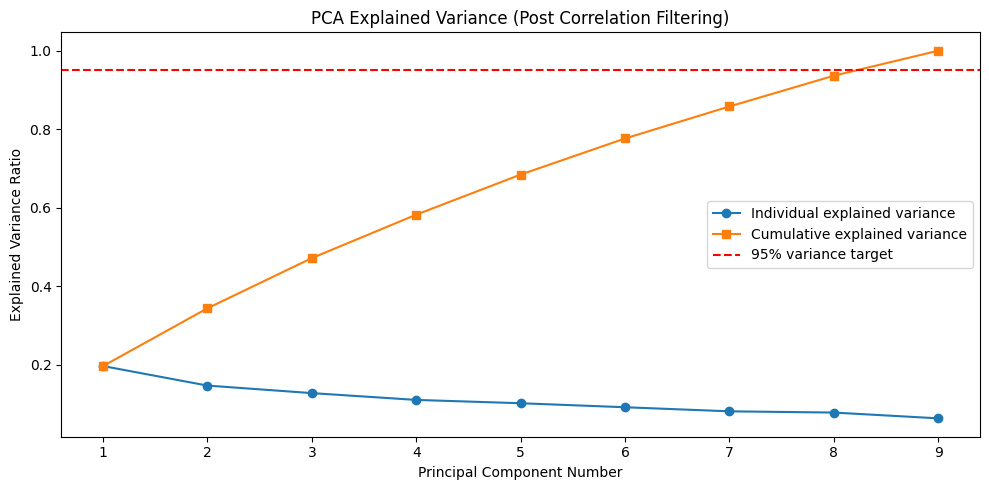


Top principal components by explained variance:
PC1: 0.1968
PC2: 0.1471
PC3: 0.1279
PC4: 0.1106
PC5: 0.1021
PC6: 0.0919
PC7: 0.0815
PC8: 0.0784
PC9: 0.0637


In [210]:
# 9.2 PCA-based further reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize filtered features before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_corr_reduced)

# Keep enough components to explain 95% variance
pca_variance_target = 0.95
pca = PCA(n_components=pca_variance_target, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    index=X_corr_reduced.index
)

explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)

print("\n" + "=" * 70)
print("9.2 PCA-BASED FEATURE REDUCTION")
print("=" * 70)
print(f"Input features before PCA: {X_corr_reduced.shape[1]}")
print(f"PCA variance retention target: {pca_variance_target:.0%}")
print(f"Number of principal components selected: {X_pca_df.shape[1]}")
print(f"Total variance retained: {cum_var[-1]:.4f} ({cum_var[-1]:.2%})")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o', label='Individual explained variance')
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='s', label='Cumulative explained variance')
plt.axhline(pca_variance_target, color='red', linestyle='--', label=f'{int(pca_variance_target*100)}% variance target')
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (Post Correlation Filtering)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop principal components by explained variance:")
for i, val in enumerate(explained[:10], start=1):
    print(f"PC{i}: {val:.4f}")

### Insights — Feature Reduction
- Correlation filtering removed redundant input information by dropping highly correlated predictors (in this run, `original_price` was removed at threshold 0.90).
- After correlation filtering, the model input dropped from 10 to 9 features, improving feature independence and reducing multicollinearity risk.
- PCA with a 95% variance-retention target selected 9 components, meaning this dataset currently has limited compressibility at that strict threshold.
- Practical interpretation: correlation filtering provided the meaningful reduction; PCA here is more useful for orthogonalization than aggressive dimensionality shrinkage unless a lower variance target (e.g., 90–92%) is accepted.

# 10. Ordered Modeling Workflow (i to m)

This section follows your requested order exactly:
- i: Normality test by analyzing skew before scaling/normalization
- k.i: If highly skewed, apply log1p before scaling/normalization
- j: Scaling/normalization for numeric features only
- j.i: Save scaler weights for demo
- k: Normality test after scaling/normalization
- l: Model training
- m: Model evaluation for multiple models and best-model saving

### Normality test by skew (before scaling/normalization)

In [211]:

import os
import json
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.preprocessing import StandardScaler

ARTIFACT_DIR = 'Project/artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Use previously prepared feature matrix X and target y if available
if 'X' not in globals() or 'y' not in globals():
    raise ValueError('X and y are not available. Please run encoding/normalization section first.')

X_work = X.copy()
y_work = pd.to_numeric(y, errors='coerce')

# Keep only rows where target is valid
valid_mask = y_work.notna()
X_work = X_work.loc[valid_mask].reset_index(drop=True)
y_work = y_work.loc[valid_mask].reset_index(drop=True)

# Numeric columns only; avoid scaling binary flags by selecting columns with > 2 unique values
numeric_cols_all = X_work.select_dtypes(include=[np.number]).columns.tolist()
scale_cols = [c for c in numeric_cols_all if X_work[c].nunique(dropna=False) > 2]

if not scale_cols:
    raise ValueError('No numeric continuous features found for skew analysis/scaling.')

skew_before = X_work[scale_cols].skew()
skew_report_before = pd.DataFrame({
    'feature': skew_before.index,
    'skew_before': skew_before.values,
    'abs_skew_before': skew_before.abs().values
}).sort_values('abs_skew_before', ascending=False)

print(skew_report_before.to_string(index=False))
print(f"\nContinuous numeric features considered: {len(scale_cols)}")

            feature  skew_before  abs_skew_before
     original_price     3.870680         3.870680
   discounted_price     3.748762         3.748762
     product_rating    -2.022797         2.022797
discount_percentage     1.979851         1.979851
      total_reviews    -0.158260         0.158260

Continuous numeric features considered: 5


### Log1p transform highly right-skewed features BEFORE scaling 

In [212]:
right_skew_threshold = 1.0
high_right_skew_cols = [c for c in scale_cols if skew_before[c] > right_skew_threshold]
log1p_shift_info = {}

for col in high_right_skew_cols:
    min_val = float(X_work[col].min())
    shift = 0.0 if min_val > -1 else (-min_val + 1.0)
    X_work[col] = np.log1p(X_work[col] + shift)
    log1p_shift_info[col] = {'shift_applied': shift}


print(f'Right-skew threshold used: skew > {right_skew_threshold}')
if high_right_skew_cols:
    print('Transformed features:')
    for c in high_right_skew_cols:
        print(f"  - {c} (shift={log1p_shift_info[c]['shift_applied']:.4f})")
else:
    print('No features required log1p transformation.')

Right-skew threshold used: skew > 1.0
Transformed features:
  - discounted_price (shift=0.0000)
  - original_price (shift=0.0000)
  - discount_percentage (shift=0.0000)


### Scaling/normalization (numeric features only)

In [213]:

cols_to_normalize = ['product_rating', 'total_reviews', 'discounted_price', 
                     'original_price', 'discount_percentage']
for col in cols_to_normalize:
    if col in X.columns:
        X[col] = (X[col] - X[col].min()) / (X[col].max() - X[col].min())

print(X.shape)
print(X.isnull().sum().sum())  # should be 0
print(X.dtypes.value_counts()) # should be all numeric

(32164, 32)
0
bool       22
float64     5
int64       5
Name: count, dtype: int64


Normality test after scaling/normalization

In [214]:
skew_after = X_work[scale_cols].skew()
skew_report_after = pd.DataFrame({
    'feature': skew_after.index,
    'skew_after': skew_after.values,
    'abs_skew_after': skew_after.abs().values
}).sort_values('abs_skew_after', ascending=False)

skew_compare = pd.merge(
    skew_report_before[['feature', 'skew_before']],
    skew_report_after[['feature', 'skew_after']],
    on='feature', how='inner'
 )
skew_compare['abs_change'] = (skew_compare['skew_after'].abs() - skew_compare['skew_before'].abs())

print(skew_report_after.to_string(index=False))

print('\nSkew change summary (negative is improvement):')
print(skew_compare.sort_values('abs_change').to_string(index=False))

# Final matrix for modeling (already encoded from earlier X, so no new dummying needed)
X_model_final = X_work.copy()
y_model_final = y_work.copy()
print(f"\nFinal modeling matrix shape: {X_model_final.shape}")

            feature  skew_after  abs_skew_after
     product_rating   -2.022797        2.022797
discount_percentage    0.887004        0.887004
     original_price    0.178754        0.178754
      total_reviews   -0.158260        0.158260
   discounted_price    0.152875        0.152875

Skew change summary (negative is improvement):
            feature  skew_before  skew_after  abs_change
     original_price     3.870680    0.178754   -3.691926
   discounted_price     3.748762    0.152875   -3.595887
discount_percentage     1.979851    0.887004   -1.092847
     product_rating    -2.022797   -2.022797    0.000000
      total_reviews    -0.158260   -0.158260    0.000000

Final modeling matrix shape: (32164, 32)
